# Culculate the performance of MMMO algorithms and save it as CSV files

In [17]:
import pandas as pd

def encode_type(type_string):
    return "".join(
        "1" if token == "max" else "0"
        for token in type_string.split("_")
    )

def build_average_rank_table(type: str, pf_shape: str, D: int) -> pd.DataFrame:

    csv_path = rf"./platemo_benchmark_results_{type}_{pf_shape}_{D}d.csv"

    encoded_type = encode_type(type)

    algorithm_names = ["HREA", "MMEAWI", "MMOEADC", "NSGAII"]

    metric_names = ["IGDX", "IGDX_Global", "HV"]

    problem_feature_names = [
        "num_epsilon_local_optima",
        "num_local_optima",
        "fdc",
        "disp_10pct",
    ]

    raw_results = pd.read_csv(csv_path)

    per_metric_rank_tables = []

    for metric_name in metric_names:
        algorithm_score_columns = [
            f"{metric_name}_{algorithm_name}"
            for algorithm_name in algorithm_names
        ]

        rank_ascending = metric_name != "HV"

        per_seed_ranks = raw_results[algorithm_score_columns].rank(
            axis=1,
            ascending=rank_ascending,
            method="average",
        )

        per_seed_ranks.columns = [
            f"{column}_rank"
            for column in algorithm_score_columns
        ]

        metric_rank_results = pd.concat(
            [raw_results[["idx", "seed"]], per_seed_ranks],
            axis=1,
        )

        per_metric_rank_tables.append(metric_rank_results)

    merged_rank_results = per_metric_rank_tables[0]

    for metric_rank_results in per_metric_rank_tables[1:]:
        merged_rank_results = merged_rank_results.merge(
            metric_rank_results,
            on=["idx", "seed"],
        )

    problem_features_by_idx = (
        raw_results.groupby("idx")[problem_feature_names]
        .first()
    )

    mean_ranks_by_idx = (
        merged_rank_results.drop(columns="seed")
        .groupby("idx")
        .mean()
    )

    average_rank_table = problem_features_by_idx.merge(
        mean_ranks_by_idx,
        left_index=True,
        right_index=True,
    ).reset_index()

    average_rank_table.rename(
        columns={"idx": "instance_id"},
        inplace=True,
    )

    average_rank_table.insert(0, "function_id", encoded_type)

    return average_rank_table

In [18]:
import pandas as pd


def encode_type(type_string):
    return "".join(
        "1" if token == "max" else "0"
        for token in type_string.split("_")
    )


def build_average_value_table(
    type: str,
    pf_shape: str,
    D: int,
) -> pd.DataFrame:

    csv_path = rf"./platemo_benchmark_results_{type}_{pf_shape}_{D}d.csv"

    encoded_type = encode_type(type)

    algorithm_names = [
        "HREA",
        "MMEAWI",
        "MMOEADC",
        "NSGAII",
    ]

    metric_names = [
        "IGDX",
        "IGDX_Global",
        "HV",
    ]

    problem_feature_names = [
        "num_epsilon_local_optima",
        "num_local_optima",
        "fdc",
        "disp_10pct",
    ]

    raw_results = pd.read_csv(csv_path)

    per_metric_score_tables = []

    for metric_name in metric_names:

        algorithm_score_columns = [
            f"{metric_name}_{algorithm_name}"
            for algorithm_name in algorithm_names
        ]

        metric_score_results = raw_results[
            ["idx", "seed"] + algorithm_score_columns
        ].copy()

        per_metric_score_tables.append(
            metric_score_results
        )

    merged_score_results = per_metric_score_tables[0]

    for metric_score_results in per_metric_score_tables[1:]:

        merged_score_results = merged_score_results.merge(
            metric_score_results,
            on=["idx", "seed"],
        )

    problem_features_by_idx = (
        raw_results.groupby("idx")[problem_feature_names]
        .first()
    )

    mean_scores_by_idx = (
        merged_score_results
        .drop(columns="seed")
        .groupby("idx")
        .mean()
    )

    average_score_table = problem_features_by_idx.merge(
        mean_scores_by_idx,
        left_index=True,
        right_index=True,
    ).reset_index()

    average_score_table.rename(
        columns={"idx": "instance_id"},
        inplace=True,
    )

    average_score_table.insert(
        0,
        "function_id",
        encoded_type,
    )

    return average_score_table

In [19]:
import pandas as pd

types = ["max_max_max", "max_max_min", "max_min_max", "max_min_min", "min_max_max", "min_max_min", "min_min_max", "min_min_min"]

for D in [2, 5, 10]:
    for pf_shape in ["convex", "concave"]:
        for score in ["score", "rank"]:
            per_d_tables = []

            for t in types:
                if score == "rank":
                    df = build_average_rank_table(t, pf_shape, D)
                else:
                    df = build_average_value_table(t, pf_shape, D)
                per_d_tables.append(df)

            merged_table = pd.concat(per_d_tables, axis=0, ignore_index=True)

            merged_table.to_csv(
                f"../platemo_average_{score}_{pf_shape}_{D}d.csv",
                index=False
            )

# Visualize the correlations between landscape feaatures and MMMO performance

   algorithm                   feature       rho
0       HREA  num_epsilon_local_optima -0.037457
1       HREA          num_local_optima -0.153035
2       HREA                       fdc  0.052073
3       HREA                disp_10pct  0.198720
4    MMEA-WI  num_epsilon_local_optima  0.291186
5    MMEA-WI          num_local_optima -0.122256
6    MMEA-WI                       fdc -0.343714
7    MMEA-WI                disp_10pct -0.013998
8   MMOEA/DC  num_epsilon_local_optima -0.840456
9   MMOEA/DC          num_local_optima -0.471181
10  MMOEA/DC                       fdc  0.529697
11  MMOEA/DC                disp_10pct -0.530073
12   NSGA-II  num_epsilon_local_optima  0.649931
13   NSGA-II          num_local_optima  0.325183
14   NSGA-II                       fdc -0.505114
15   NSGA-II                disp_10pct  0.277683


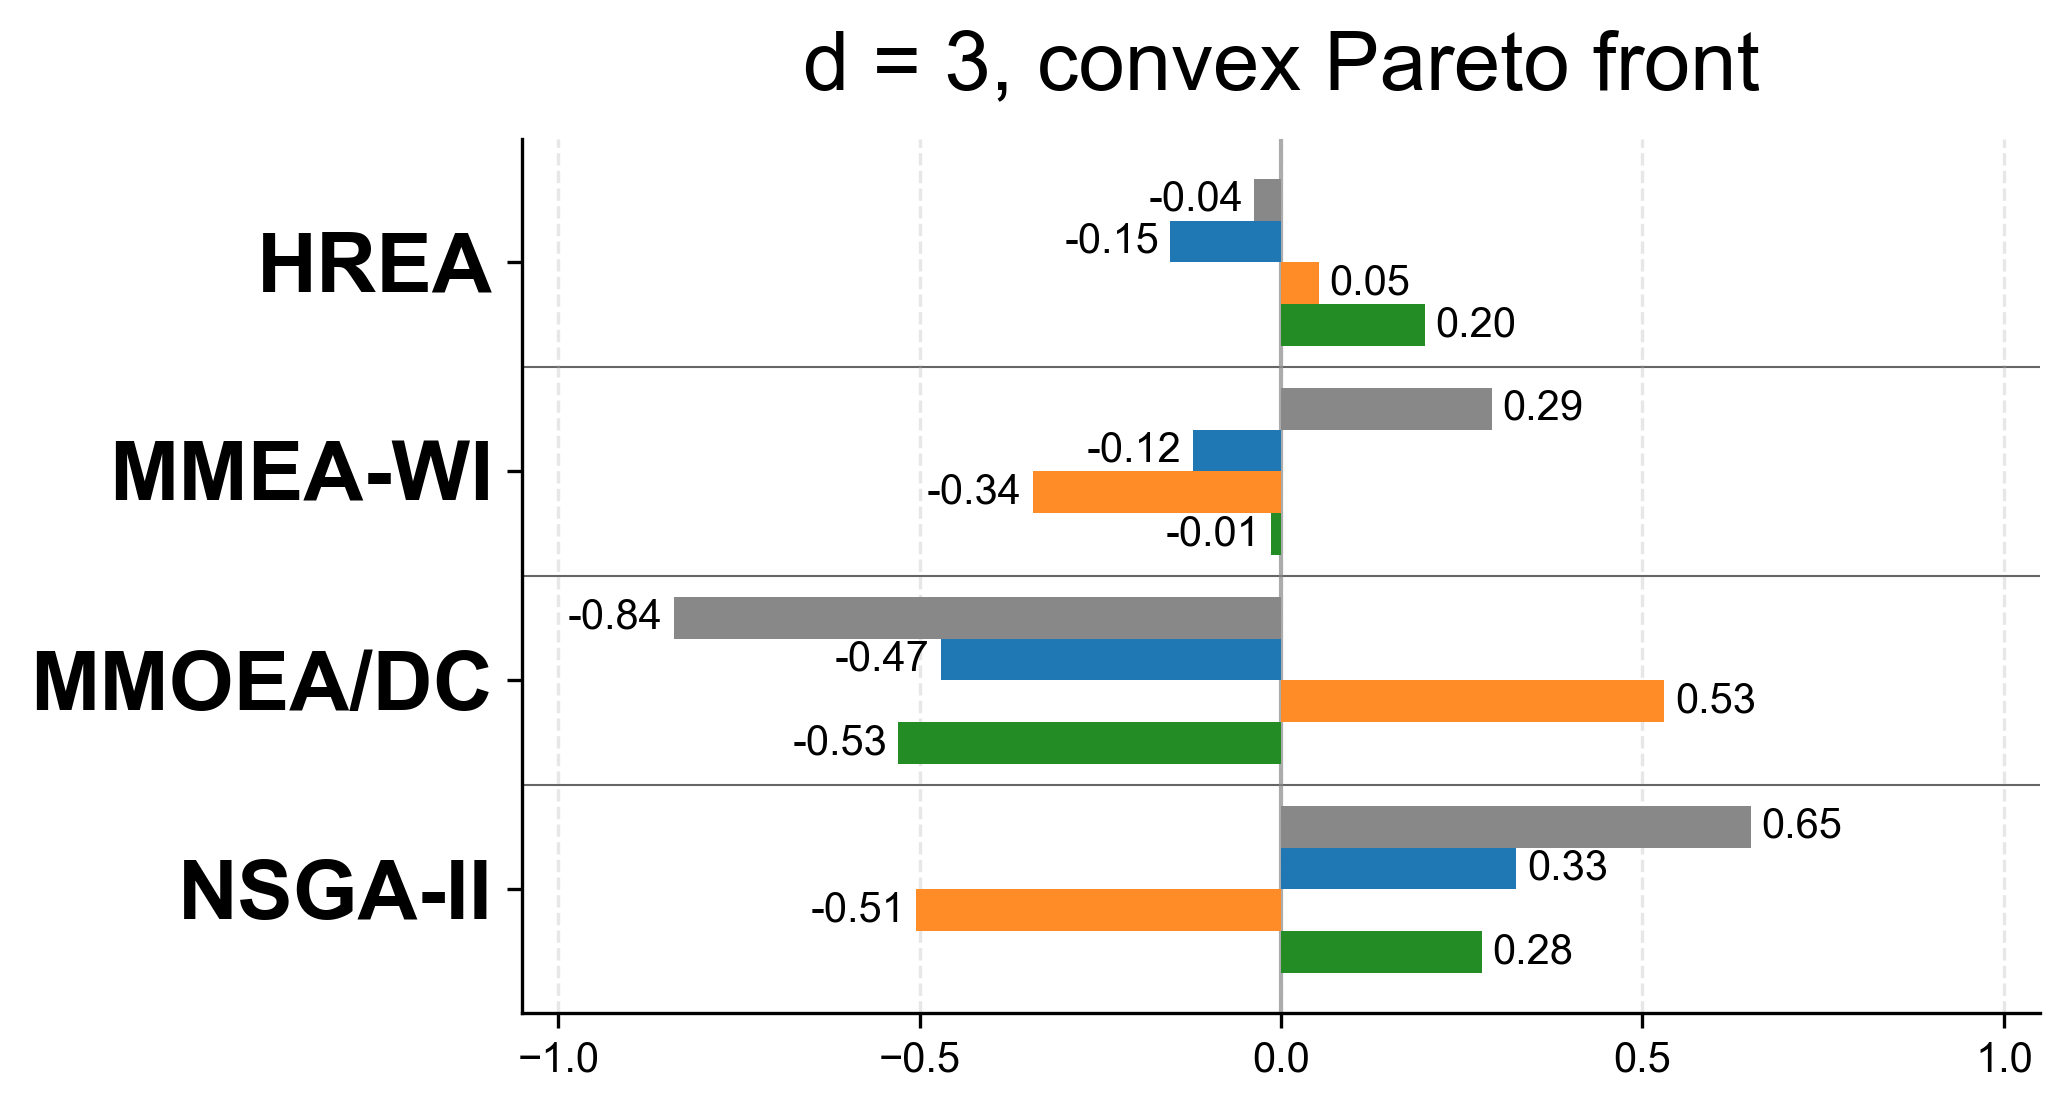

Saved: ..\spearman_rank_convex_2d.svg
   algorithm                   feature       rho
0       HREA  num_epsilon_local_optima -0.746557
1       HREA          num_local_optima -0.672748
2       HREA                       fdc  0.146602
3       HREA                disp_10pct  0.084885
4    MMEA-WI  num_epsilon_local_optima  0.519427
5    MMEA-WI          num_local_optima  0.192359
6    MMEA-WI                       fdc -0.453152
7    MMEA-WI                disp_10pct  0.093494
8   MMOEA/DC  num_epsilon_local_optima -0.461427
9   MMOEA/DC          num_local_optima -0.147635
10  MMOEA/DC                       fdc  0.779214
11  MMOEA/DC                disp_10pct -0.452423
12   NSGA-II  num_epsilon_local_optima  0.697154
13   NSGA-II          num_local_optima  0.357930
14   NSGA-II                       fdc -0.532968
15   NSGA-II                disp_10pct  0.327783


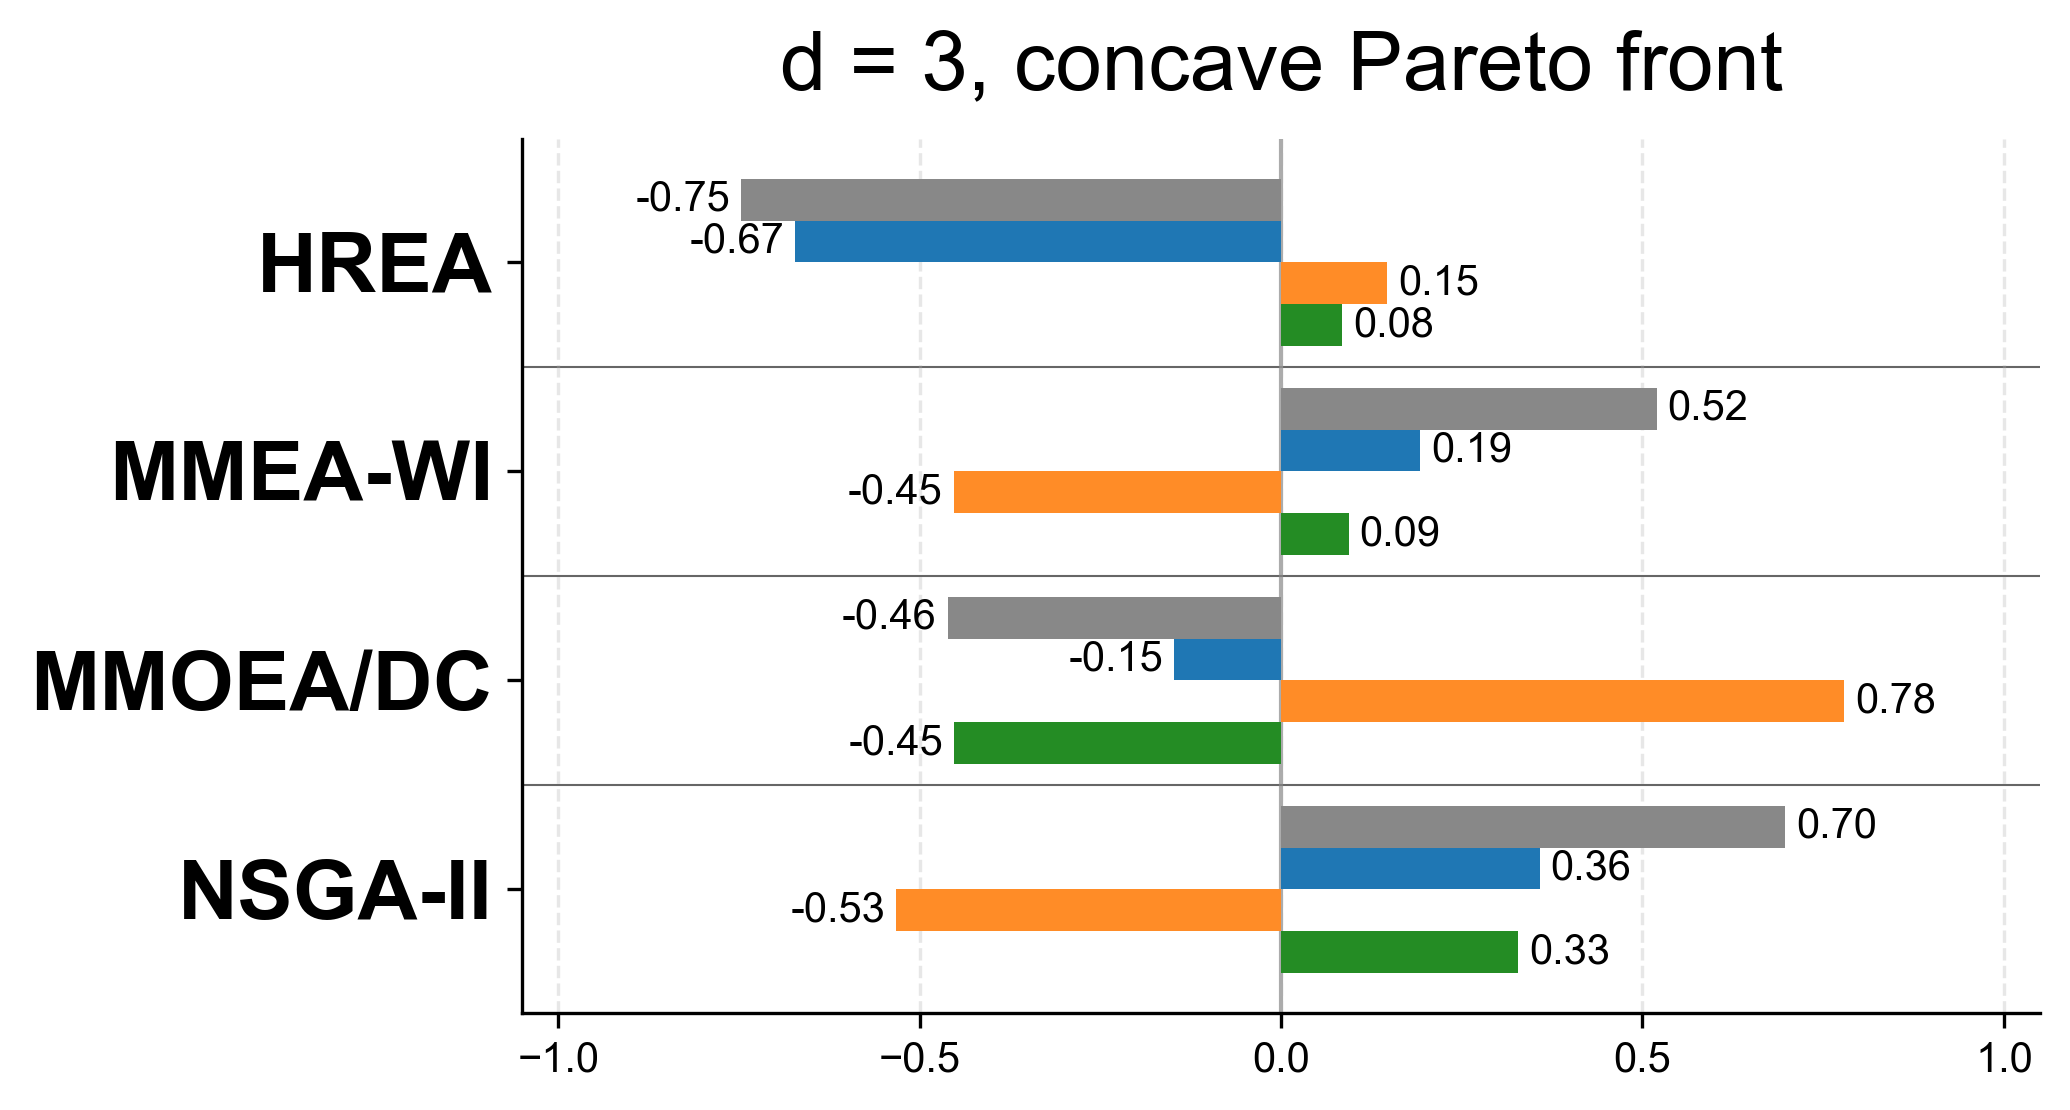

Saved: ..\spearman_rank_concave_2d.svg
   algorithm                   feature       rho
0       HREA  num_epsilon_local_optima  0.755492
1       HREA          num_local_optima  0.453611
2       HREA                       fdc -0.555042
3       HREA                disp_10pct  0.450185
4    MMEA-WI  num_epsilon_local_optima  0.708857
5    MMEA-WI          num_local_optima  0.363510
6    MMEA-WI                       fdc -0.557614
7    MMEA-WI                disp_10pct  0.492350
8   MMOEA/DC  num_epsilon_local_optima  0.841455
9   MMOEA/DC          num_local_optima  0.655321
10  MMOEA/DC                       fdc -0.340232
11  MMOEA/DC                disp_10pct  0.156117
12   NSGA-II  num_epsilon_local_optima  0.666703
13   NSGA-II          num_local_optima  0.322989
14   NSGA-II                       fdc -0.627014
15   NSGA-II                disp_10pct  0.608980


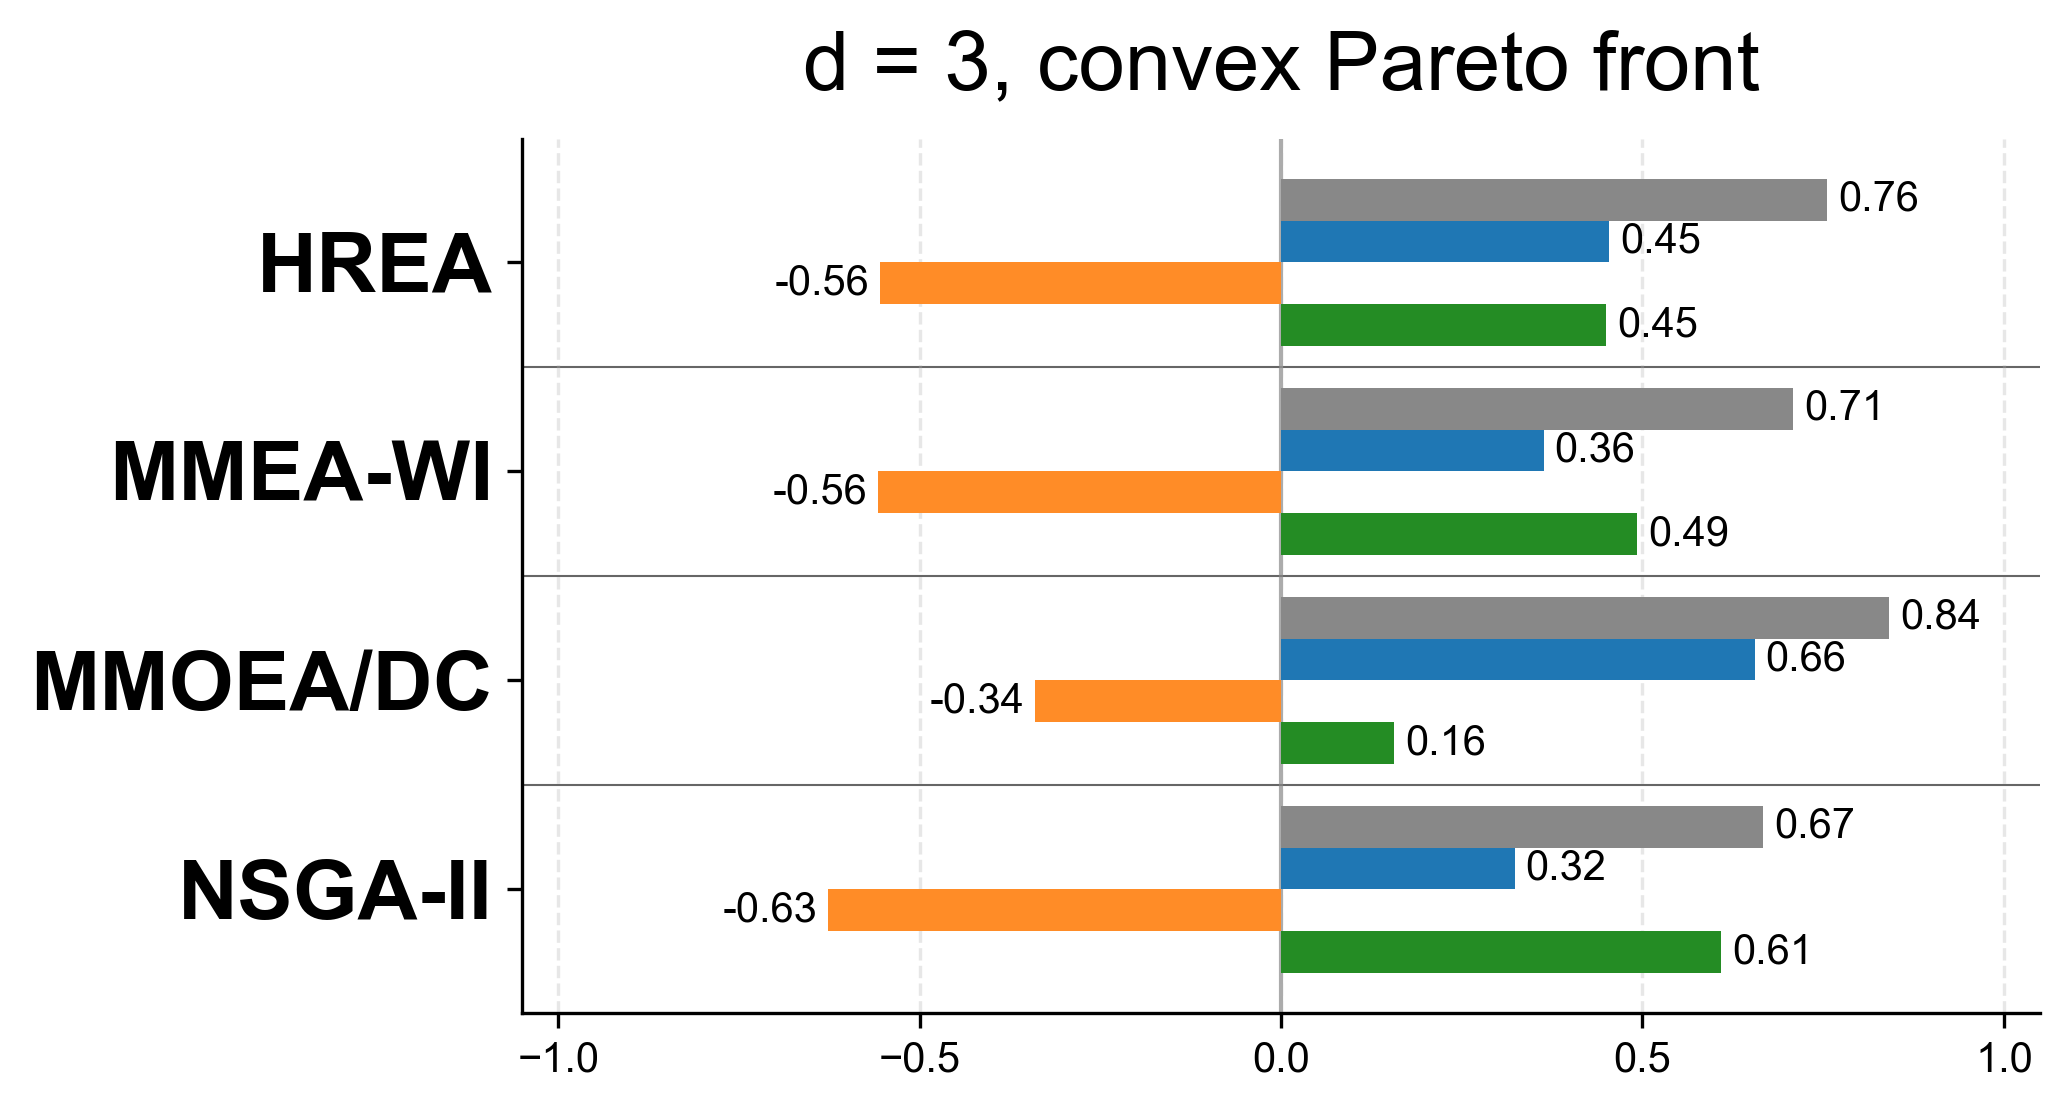

Saved: ..\spearman_score_convex_2d.svg
   algorithm                   feature       rho
0       HREA  num_epsilon_local_optima  0.412396
1       HREA          num_local_optima  0.123855
2       HREA                       fdc -0.769321
3       HREA                disp_10pct  0.268894
4    MMEA-WI  num_epsilon_local_optima  0.670334
5    MMEA-WI          num_local_optima  0.332614
6    MMEA-WI                       fdc -0.596298
7    MMEA-WI                disp_10pct  0.460200
8   MMOEA/DC  num_epsilon_local_optima  0.860938
9   MMOEA/DC          num_local_optima  0.648698
10  MMOEA/DC                       fdc -0.351007
11  MMOEA/DC                disp_10pct  0.185843
12   NSGA-II  num_epsilon_local_optima  0.661202
13   NSGA-II          num_local_optima  0.314809
14   NSGA-II                       fdc -0.630410
15   NSGA-II                disp_10pct  0.615130


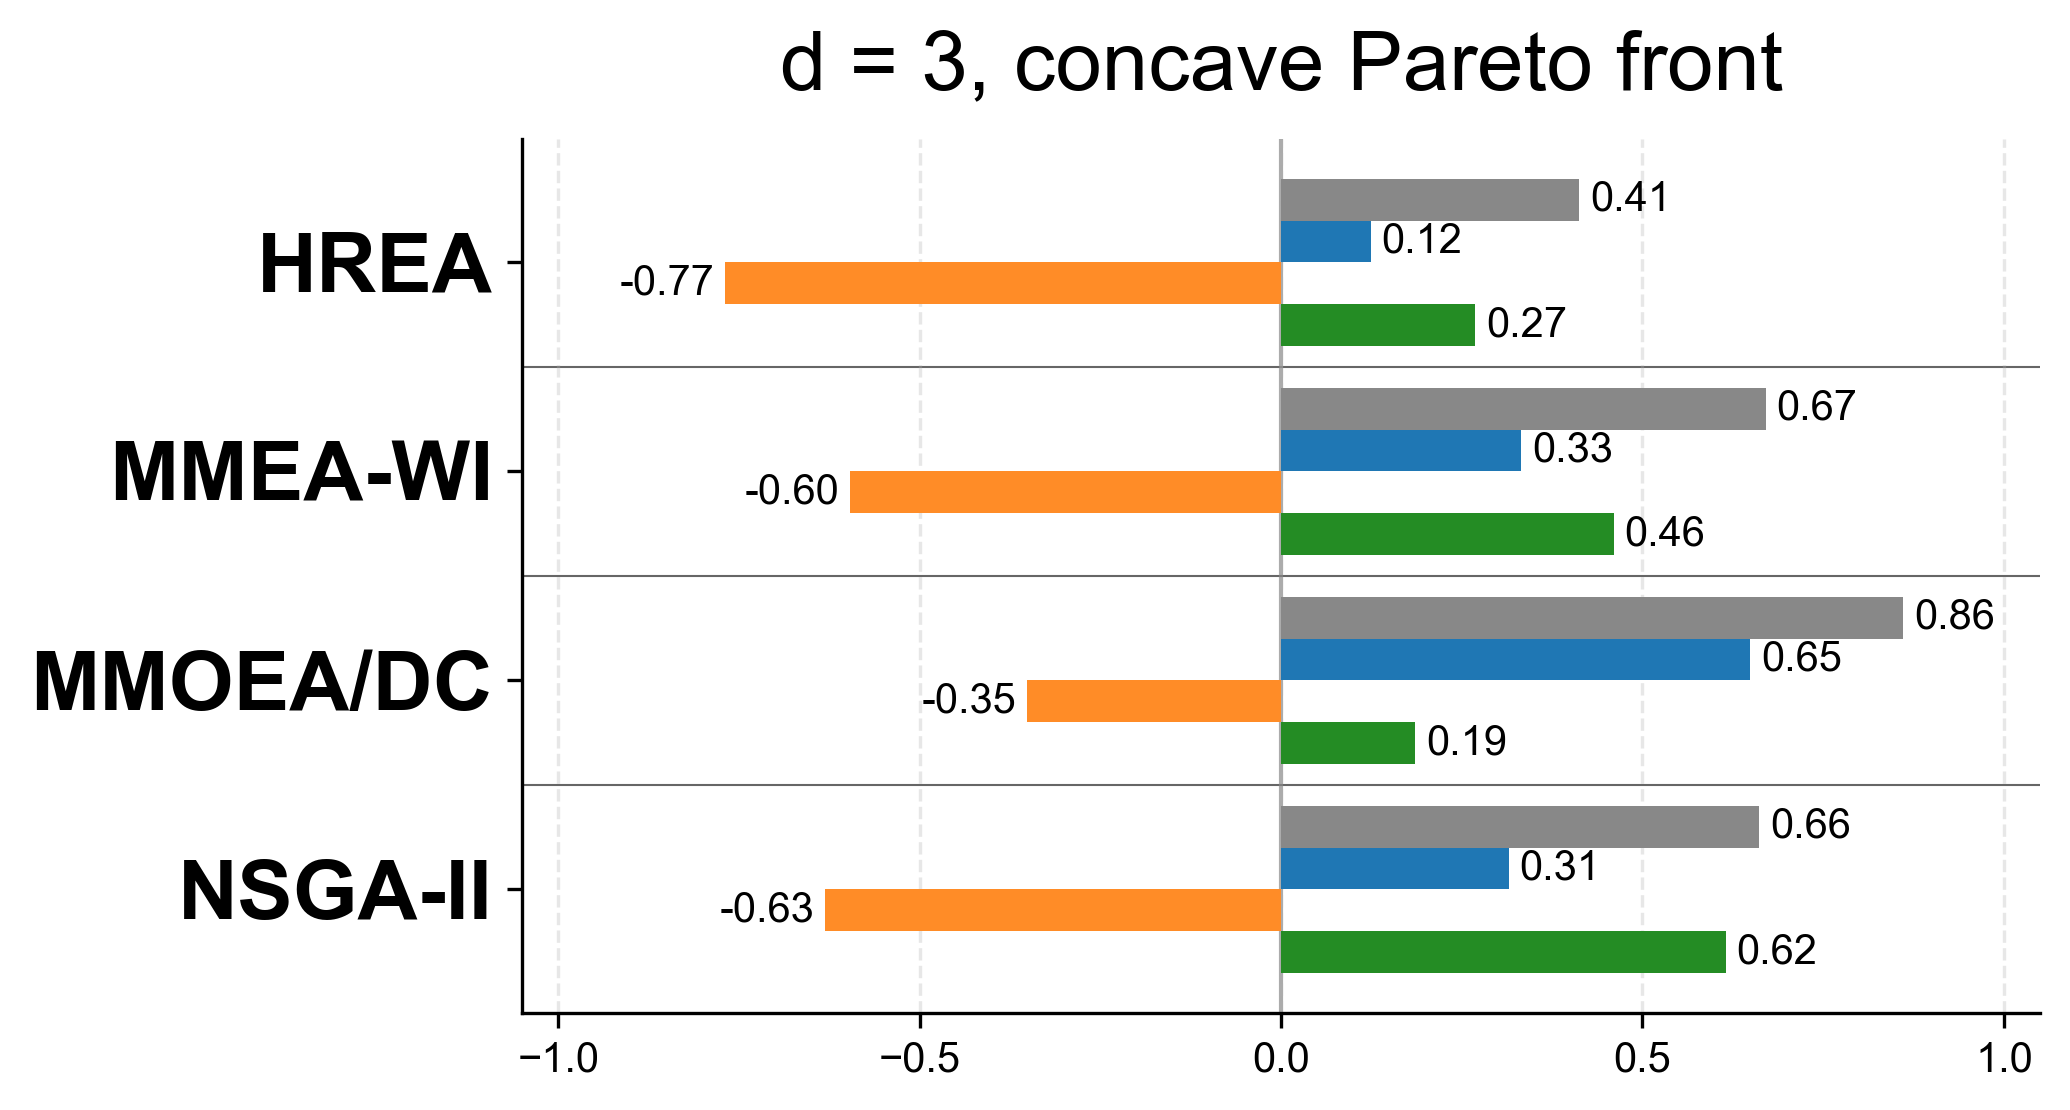

Saved: ..\spearman_score_concave_2d.svg
   algorithm                   feature       rho
0       HREA  num_epsilon_local_optima  0.330516
1       HREA          num_local_optima  0.537911
2       HREA                       fdc  0.345649
3       HREA                disp_10pct  0.353932
4    MMEA-WI  num_epsilon_local_optima  0.475062
5    MMEA-WI          num_local_optima  0.180811
6    MMEA-WI                       fdc -0.418473
7    MMEA-WI                disp_10pct  0.516129
8   MMOEA/DC  num_epsilon_local_optima -0.567190
9   MMOEA/DC          num_local_optima -0.361903
10  MMOEA/DC                       fdc  0.421649
11  MMOEA/DC                disp_10pct -0.599468
12   NSGA-II  num_epsilon_local_optima -0.122641
13   NSGA-II          num_local_optima -0.539173
14   NSGA-II                       fdc -0.254079
15   NSGA-II                disp_10pct -0.315853


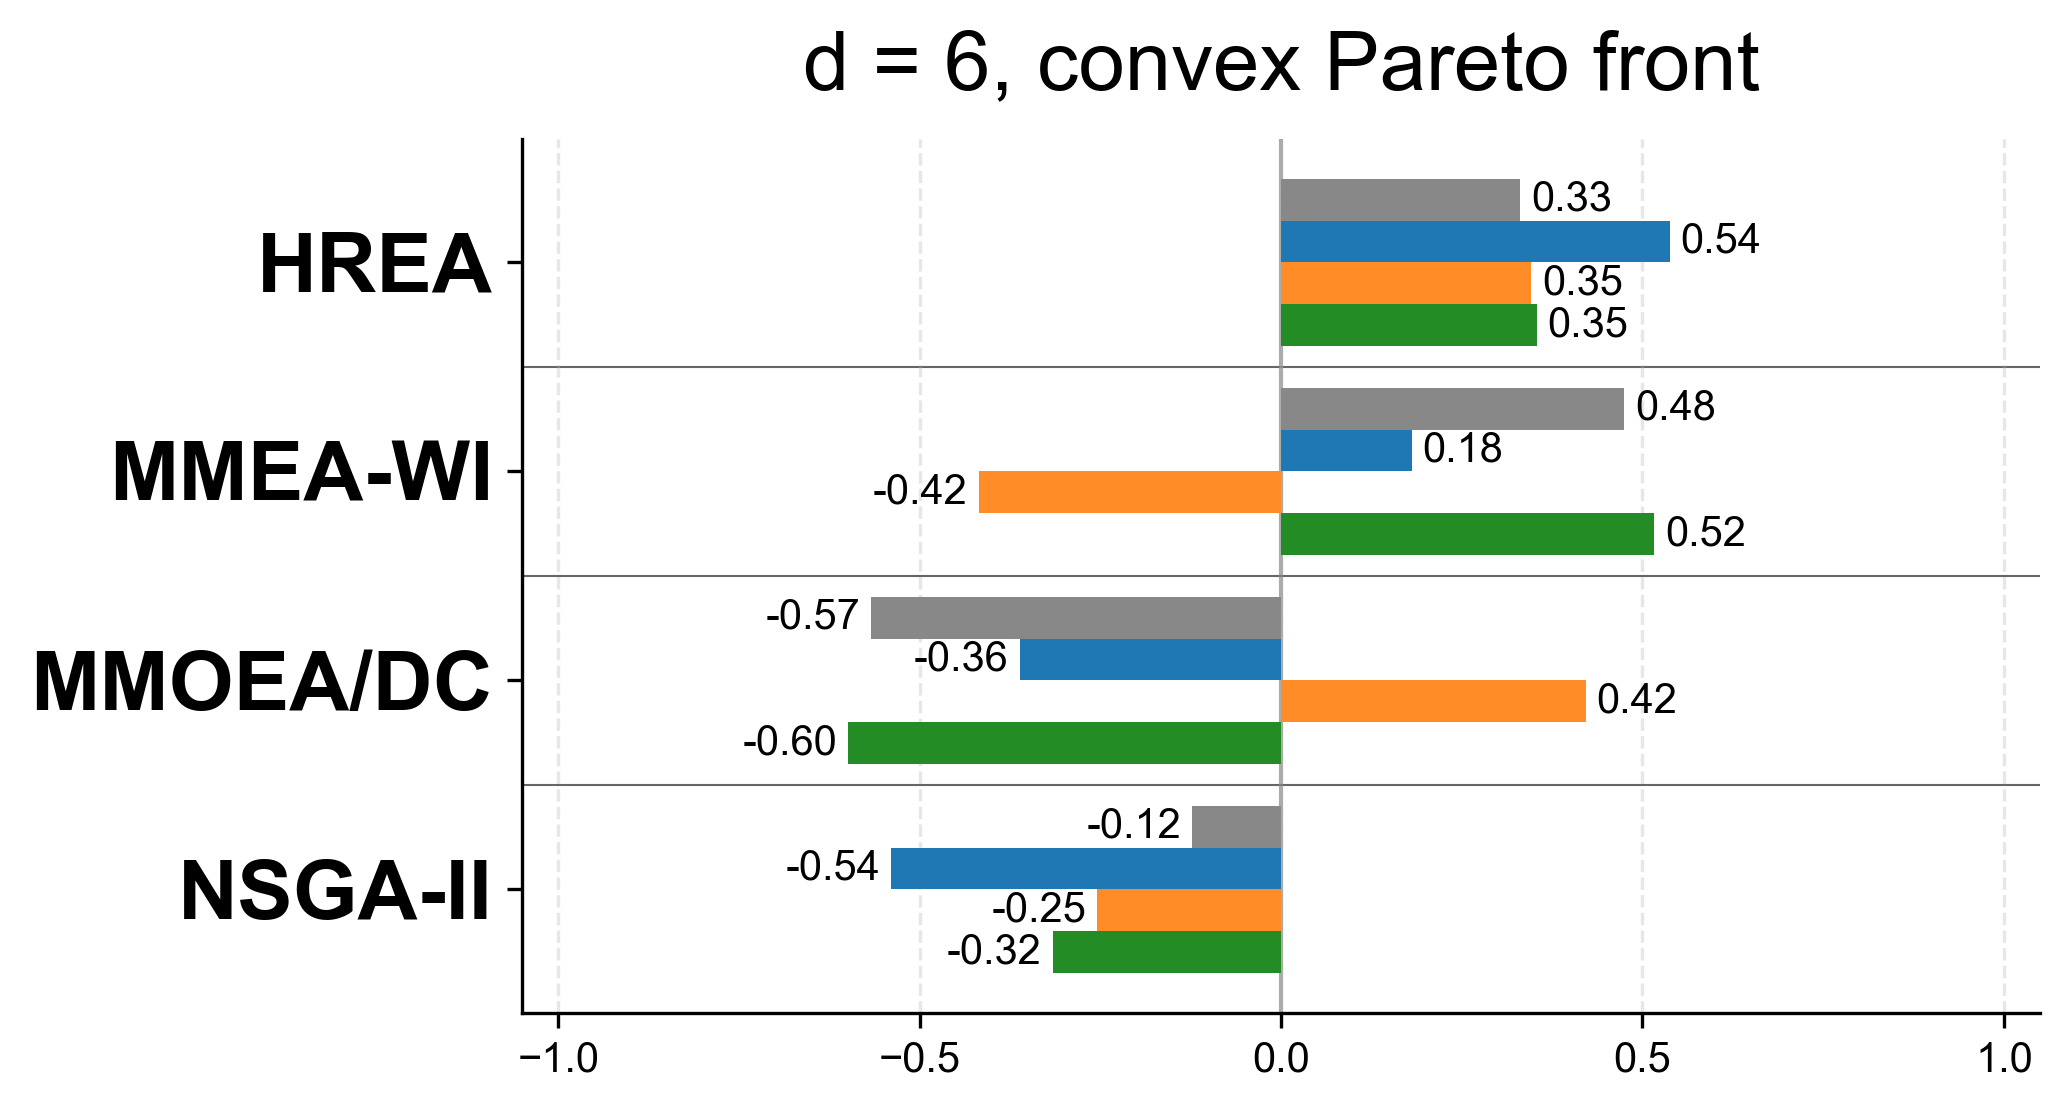

Saved: ..\spearman_rank_convex_5d.svg
   algorithm                   feature       rho
0       HREA  num_epsilon_local_optima -0.382704
1       HREA          num_local_optima -0.218734
2       HREA                       fdc  0.423268
3       HREA                disp_10pct -0.163470
4    MMEA-WI  num_epsilon_local_optima  0.779034
5    MMEA-WI          num_local_optima  0.558072
6    MMEA-WI                       fdc -0.370834
7    MMEA-WI                disp_10pct  0.706996
8   MMOEA/DC  num_epsilon_local_optima -0.126556
9   MMOEA/DC          num_local_optima  0.239309
10  MMOEA/DC                       fdc  0.228942
11  MMOEA/DC                disp_10pct -0.209920
12   NSGA-II  num_epsilon_local_optima -0.015415
13   NSGA-II          num_local_optima -0.354526
14   NSGA-II                       fdc -0.370508
15   NSGA-II                disp_10pct -0.229391


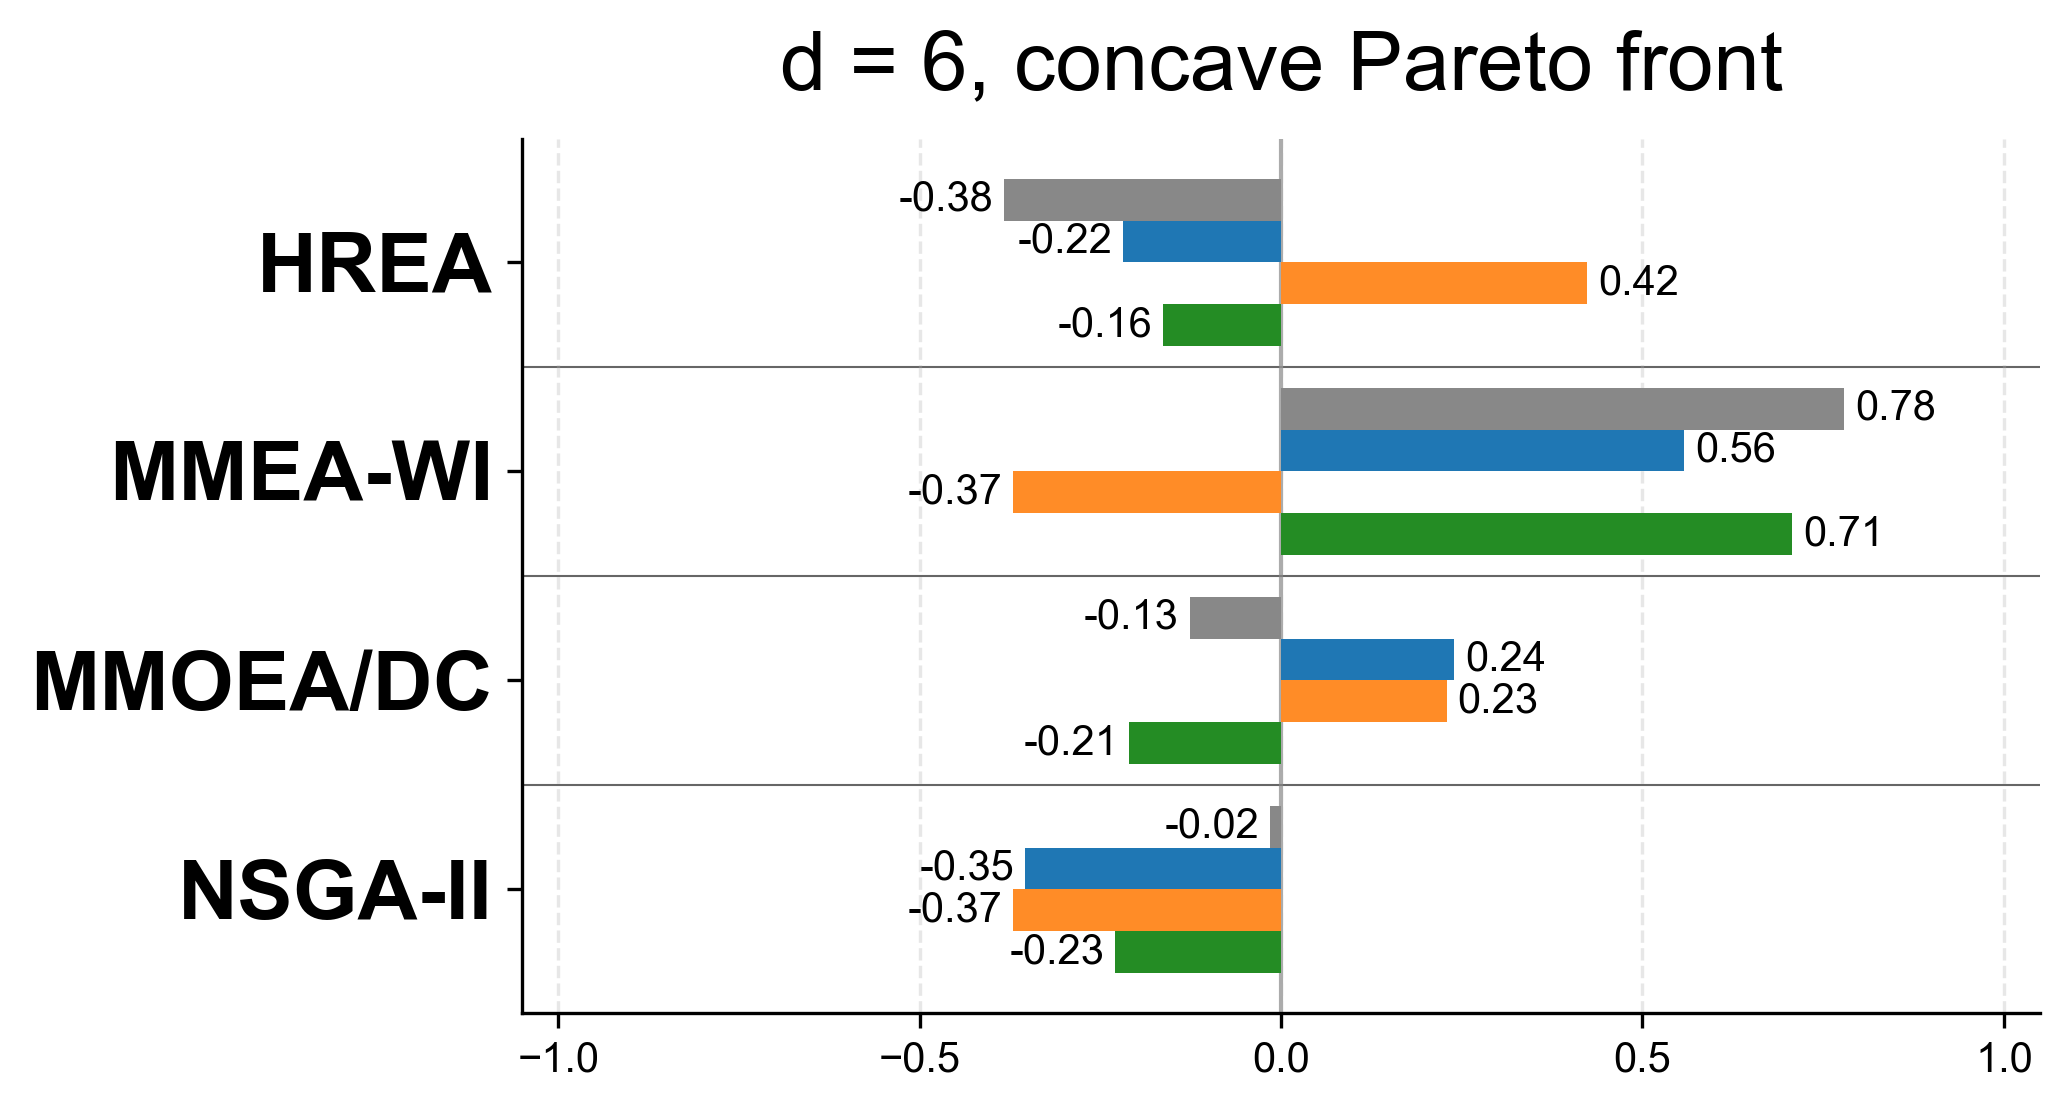

Saved: ..\spearman_rank_concave_5d.svg
   algorithm                   feature       rho
0       HREA  num_epsilon_local_optima  0.790378
1       HREA          num_local_optima  0.394710
2       HREA                       fdc -0.337399
3       HREA                disp_10pct  0.814416
4    MMEA-WI  num_epsilon_local_optima  0.817264
5    MMEA-WI          num_local_optima  0.401137
6    MMEA-WI                       fdc -0.460658
7    MMEA-WI                disp_10pct  0.865586
8   MMOEA/DC  num_epsilon_local_optima  0.257919
9   MMOEA/DC          num_local_optima  0.229169
10  MMOEA/DC                       fdc -0.753859
11  MMOEA/DC                disp_10pct  0.220400
12   NSGA-II  num_epsilon_local_optima  0.718372
13   NSGA-II          num_local_optima  0.209780
14   NSGA-II                       fdc -0.484001
15   NSGA-II                disp_10pct  0.836873


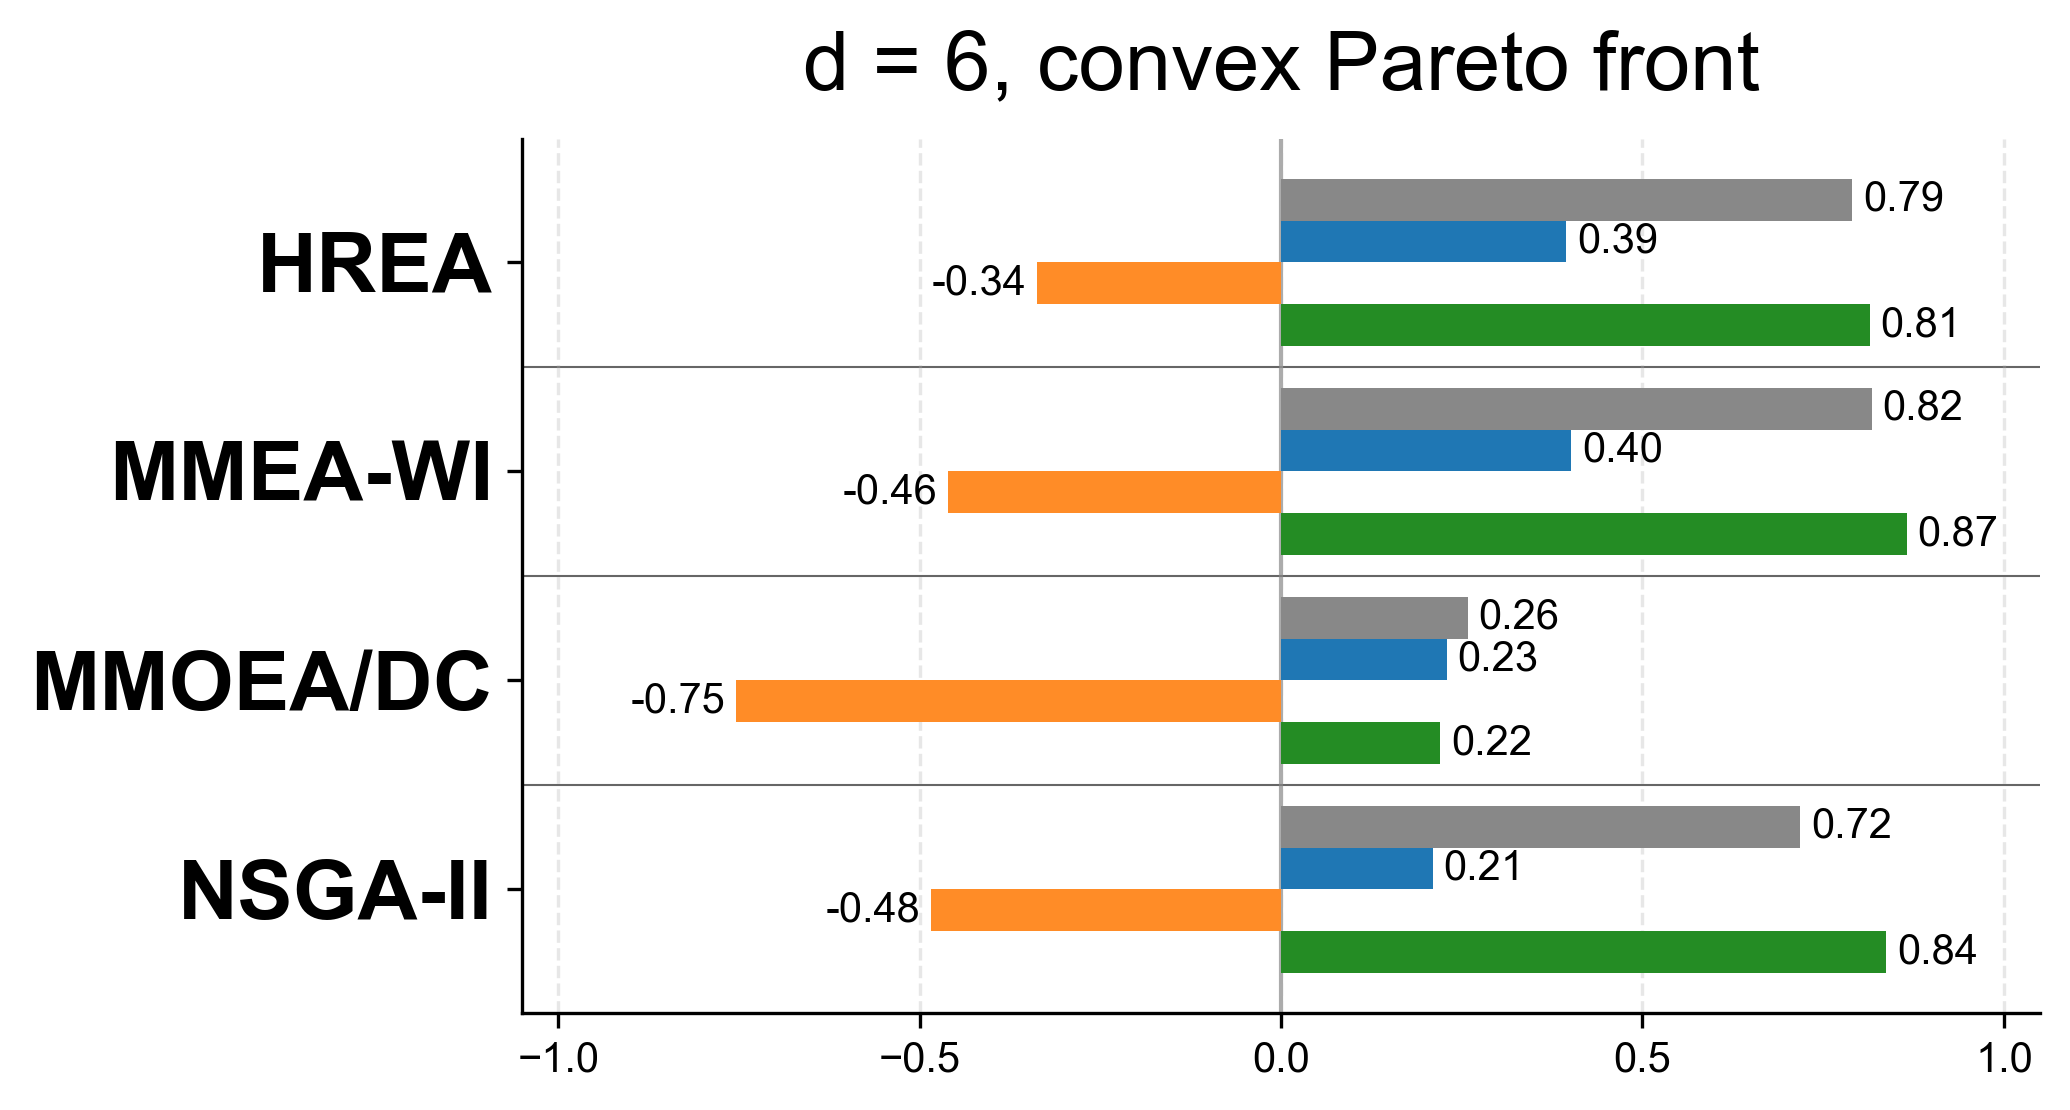

Saved: ..\spearman_score_convex_5d.svg
   algorithm                   feature       rho
0       HREA  num_epsilon_local_optima  0.464773
1       HREA          num_local_optima -0.055899
2       HREA                       fdc -0.495190
3       HREA                disp_10pct  0.588108
4    MMEA-WI  num_epsilon_local_optima  0.801753
5    MMEA-WI          num_local_optima  0.395557
6    MMEA-WI                       fdc -0.432873
7    MMEA-WI                disp_10pct  0.861429
8   MMOEA/DC  num_epsilon_local_optima  0.319427
9   MMOEA/DC          num_local_optima  0.274621
10  MMOEA/DC                       fdc -0.741519
11  MMOEA/DC                disp_10pct  0.261885
12   NSGA-II  num_epsilon_local_optima  0.703985
13   NSGA-II          num_local_optima  0.198290
14   NSGA-II                       fdc -0.476332
15   NSGA-II                disp_10pct  0.839428


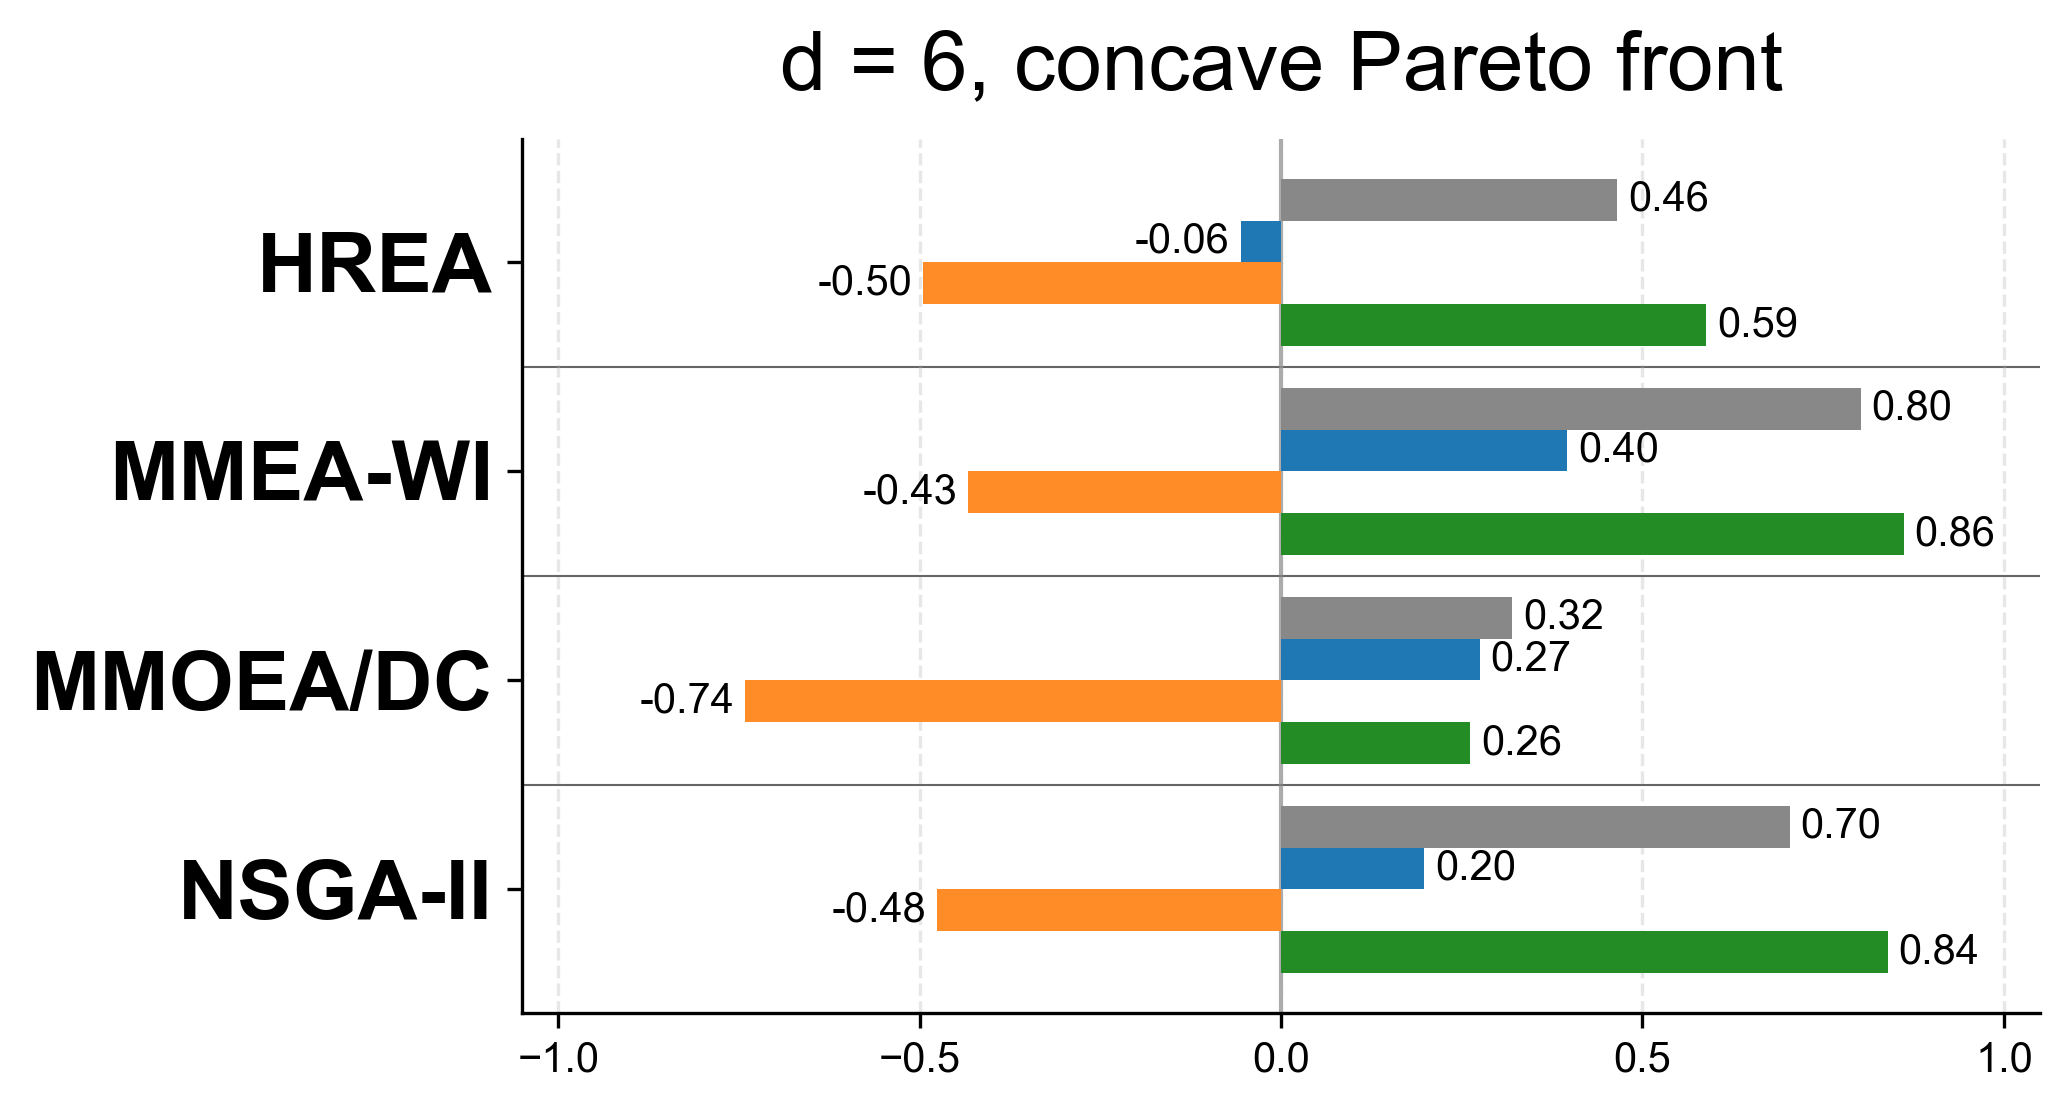

Saved: ..\spearman_score_concave_5d.svg
   algorithm                   feature       rho
0       HREA  num_epsilon_local_optima  0.560168
1       HREA          num_local_optima  0.776684
2       HREA                       fdc -0.077440
3       HREA                disp_10pct  0.607374
4    MMEA-WI  num_epsilon_local_optima -0.045192
5    MMEA-WI          num_local_optima -0.360415
6    MMEA-WI                       fdc -0.010196
7    MMEA-WI                disp_10pct -0.198766
8   MMOEA/DC  num_epsilon_local_optima -0.318476
9   MMOEA/DC          num_local_optima -0.030034
10  MMOEA/DC                       fdc -0.039211
11  MMOEA/DC                disp_10pct -0.143258
12   NSGA-II  num_epsilon_local_optima -0.191991
13   NSGA-II          num_local_optima -0.549503
14   NSGA-II                       fdc -0.023248
15   NSGA-II                disp_10pct -0.332850


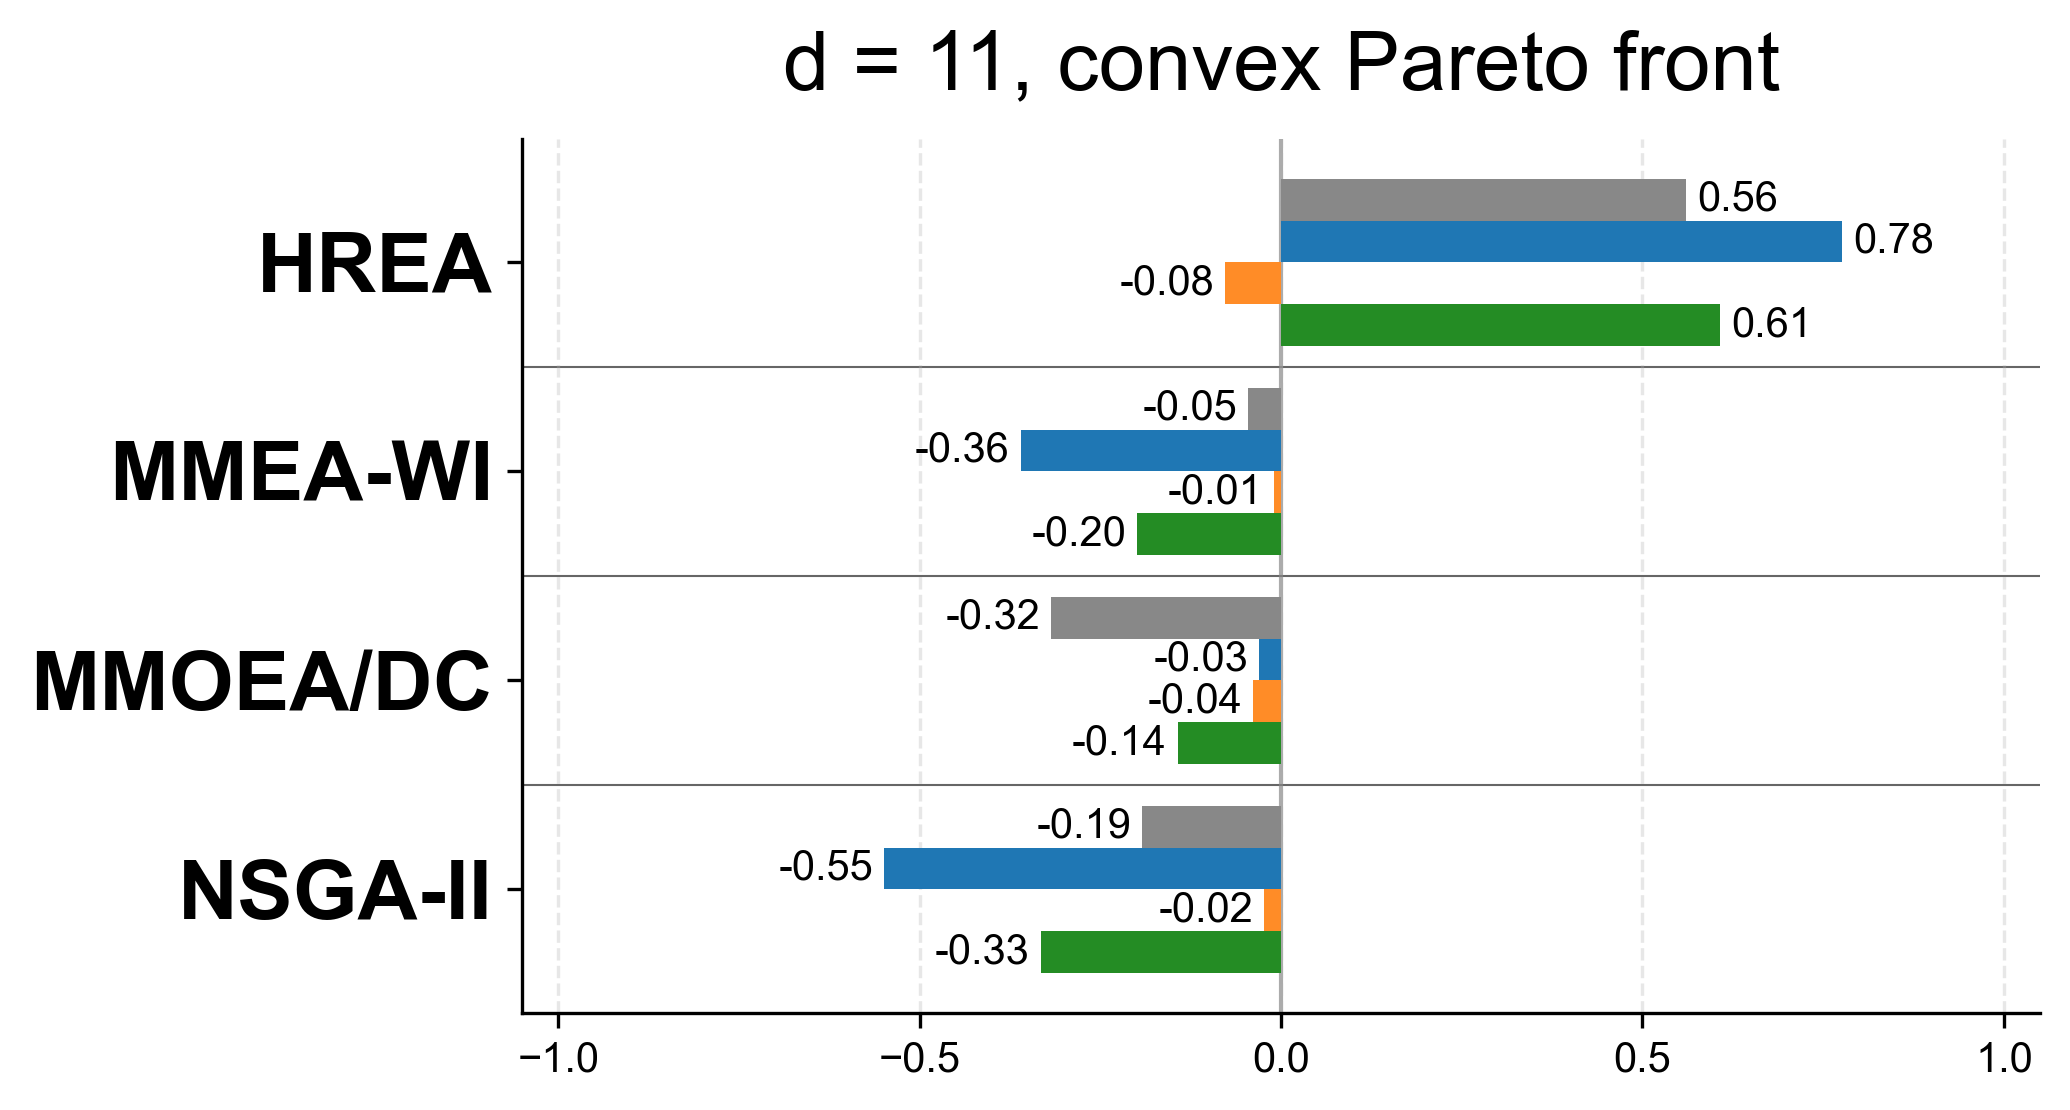

Saved: ..\spearman_rank_convex_10d.svg
   algorithm                   feature       rho
0       HREA  num_epsilon_local_optima  0.133088
1       HREA          num_local_optima  0.204591
2       HREA                       fdc  0.413090
3       HREA                disp_10pct  0.012714
4    MMEA-WI  num_epsilon_local_optima  0.483761
5    MMEA-WI          num_local_optima  0.360365
6    MMEA-WI                       fdc -0.373081
7    MMEA-WI                disp_10pct  0.434998
8   MMOEA/DC  num_epsilon_local_optima -0.294458
9   MMOEA/DC          num_local_optima  0.198646
10  MMOEA/DC                       fdc -0.353752
11  MMOEA/DC                disp_10pct  0.132815
12   NSGA-II  num_epsilon_local_optima -0.237135
13   NSGA-II          num_local_optima -0.523160
14   NSGA-II                       fdc -0.083670
15   NSGA-II                disp_10pct -0.290140


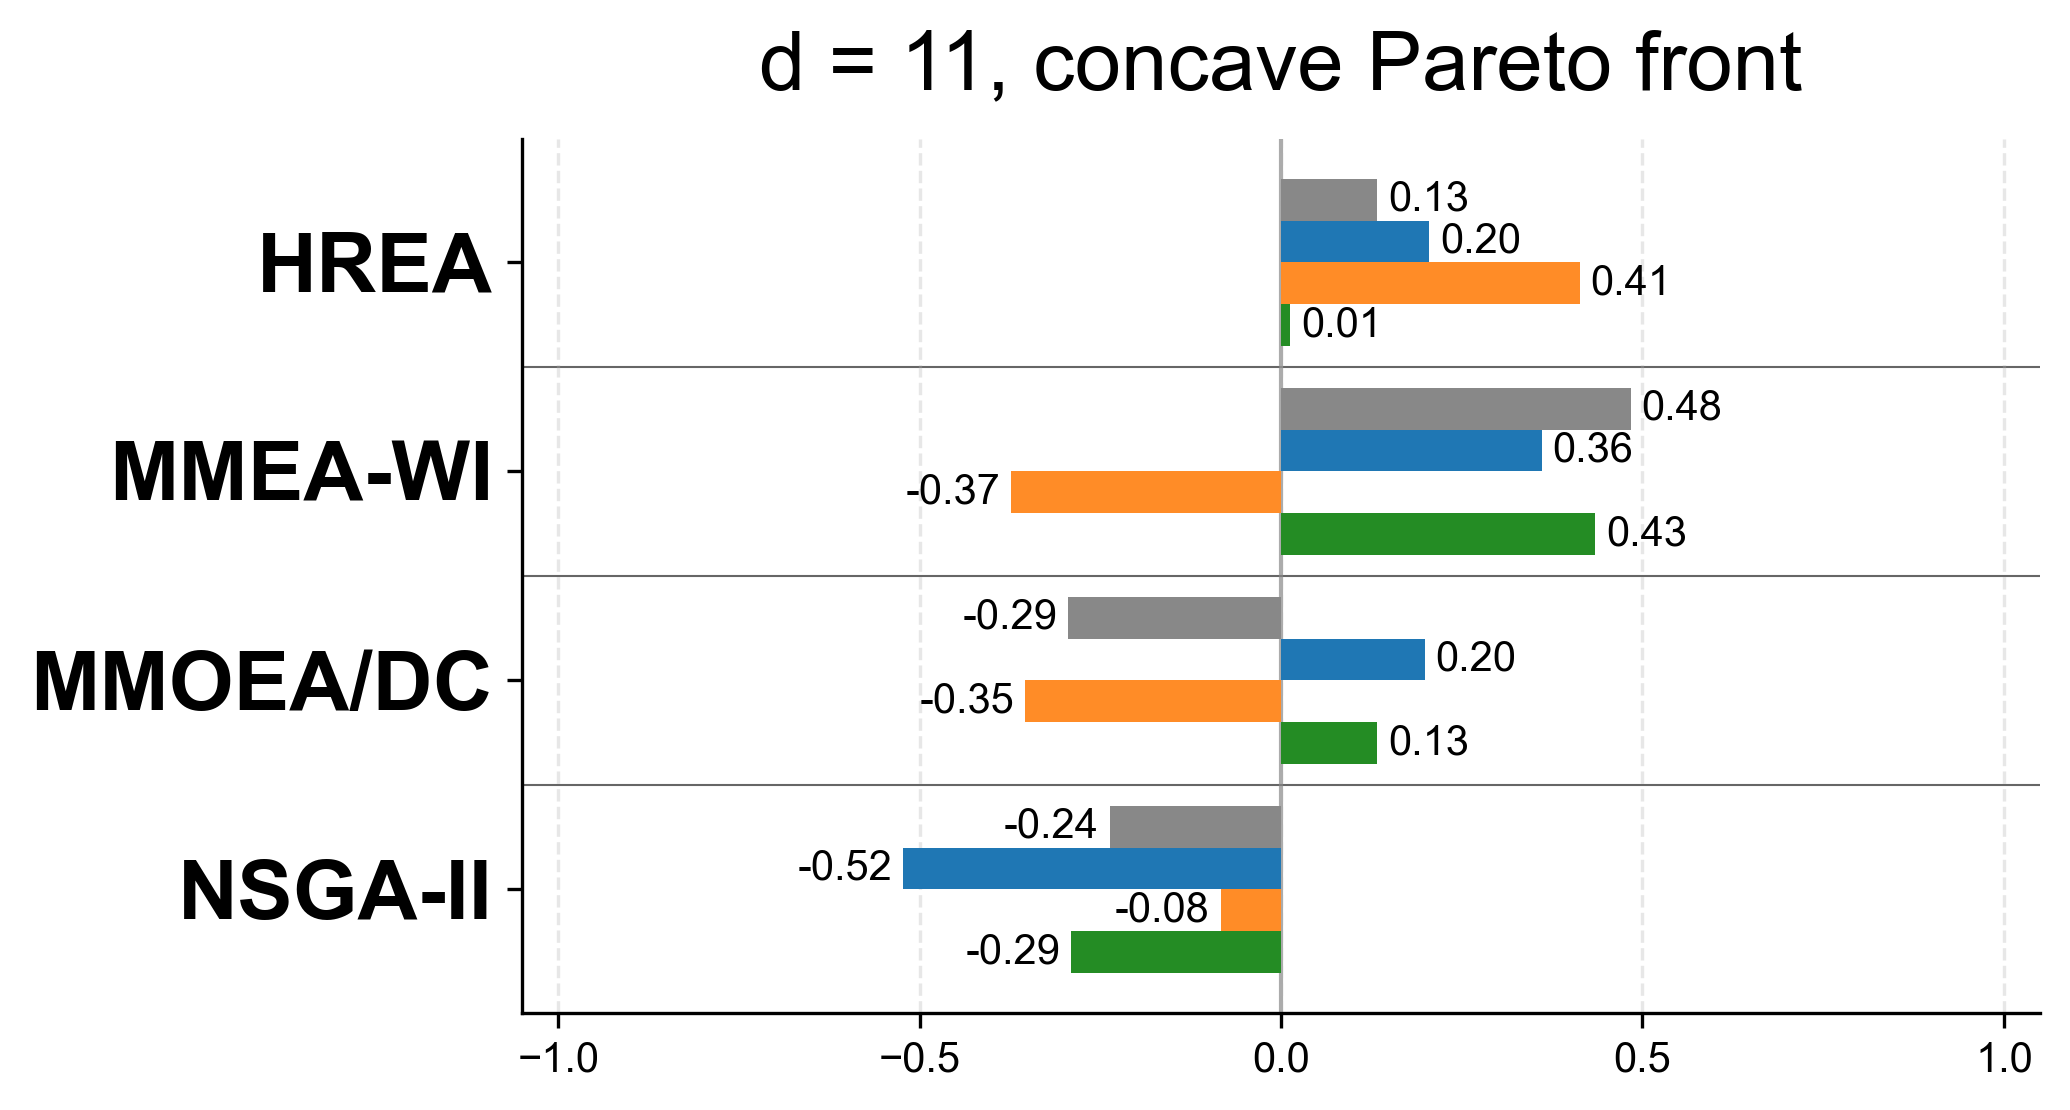

Saved: ..\spearman_rank_concave_10d.svg
   algorithm                   feature       rho
0       HREA  num_epsilon_local_optima  0.772190
1       HREA          num_local_optima  0.752037
2       HREA                       fdc -0.711419
3       HREA                disp_10pct  0.890081
4    MMEA-WI  num_epsilon_local_optima  0.499564
5    MMEA-WI          num_local_optima  0.549795
6    MMEA-WI                       fdc -0.828310
7    MMEA-WI                disp_10pct  0.738855
8   MMOEA/DC  num_epsilon_local_optima  0.135339
9   MMOEA/DC          num_local_optima  0.117936
10  MMOEA/DC                       fdc -0.726994
11  MMOEA/DC                disp_10pct  0.316131
12   NSGA-II  num_epsilon_local_optima  0.384680
13   NSGA-II          num_local_optima  0.405970
14   NSGA-II                       fdc -0.888098
15   NSGA-II                disp_10pct  0.628794


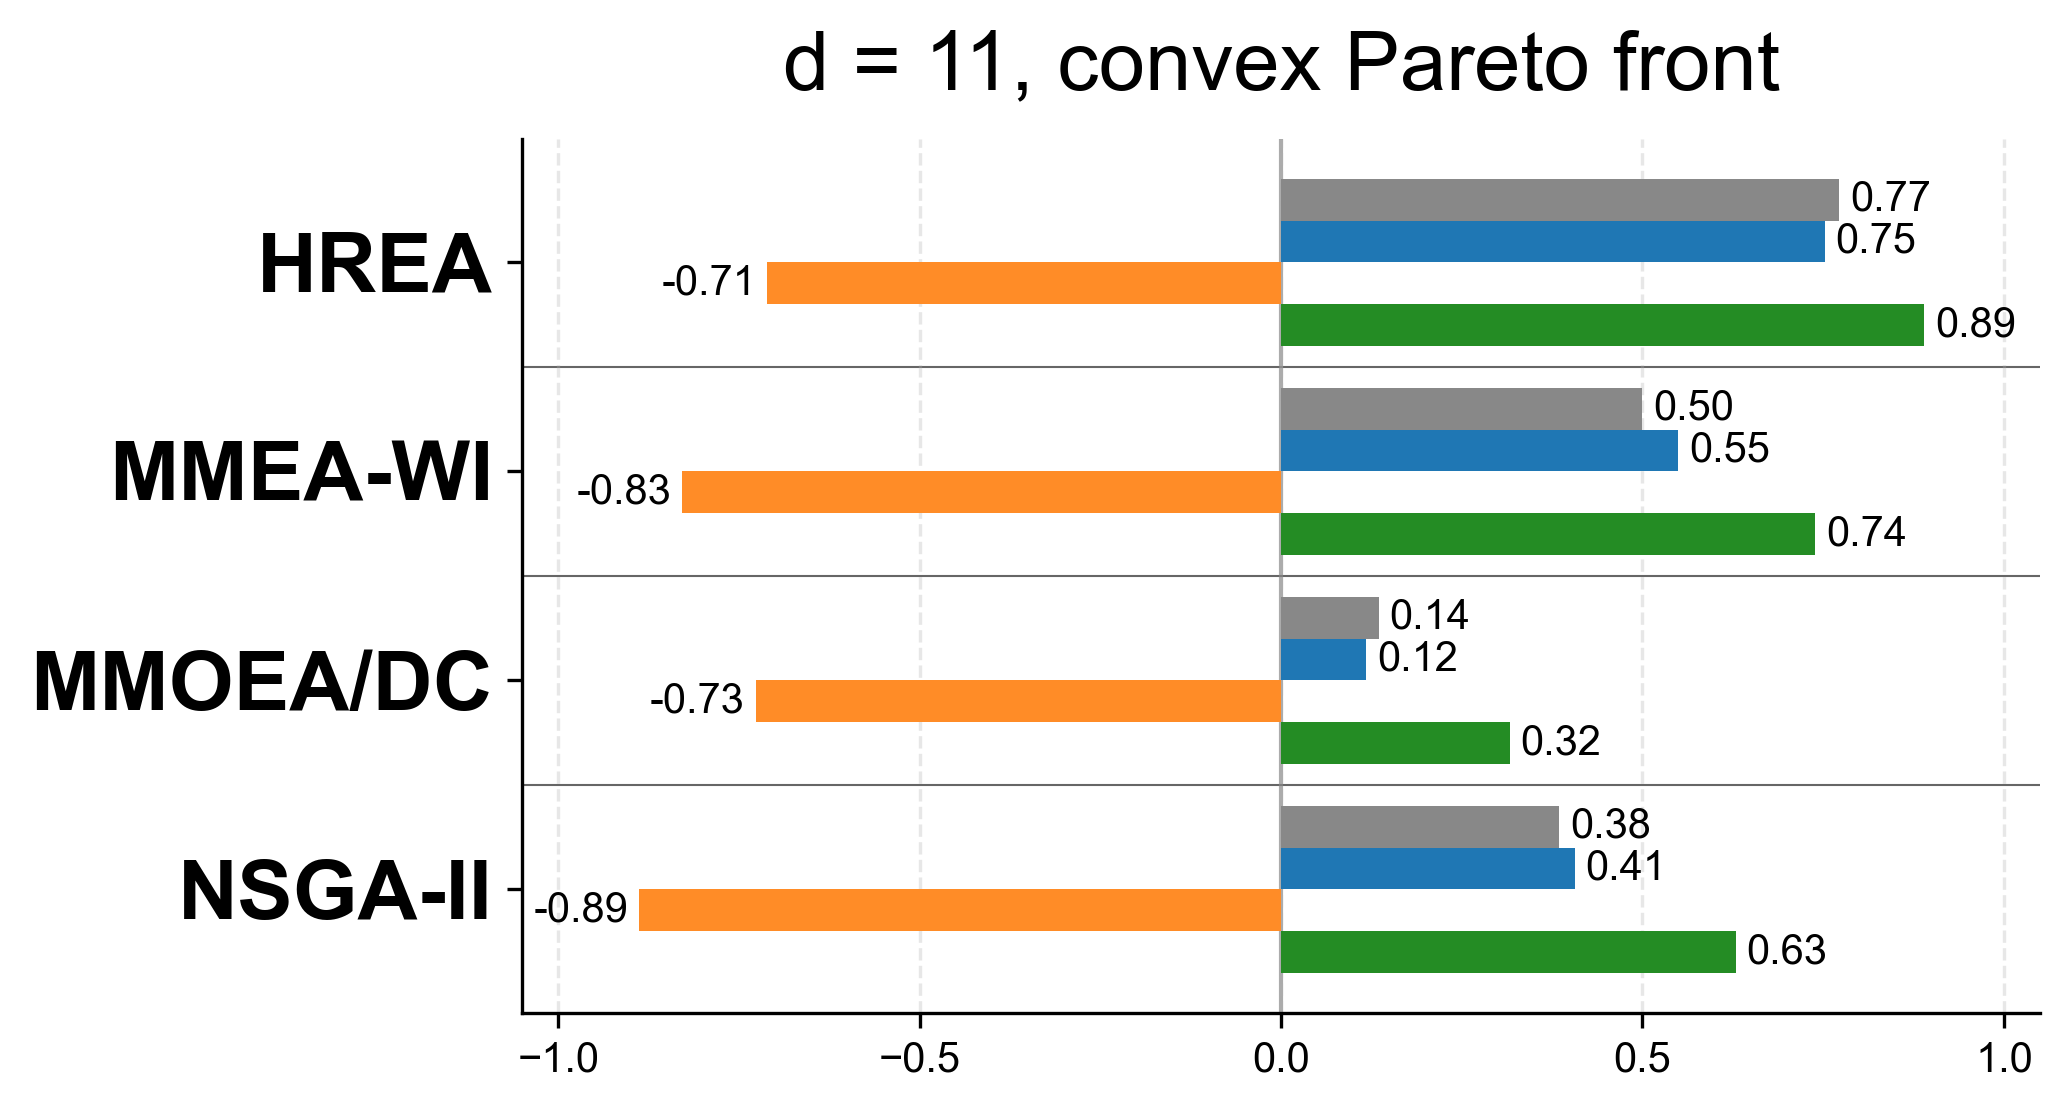

Saved: ..\spearman_score_convex_10d.svg
   algorithm                   feature       rho
0       HREA  num_epsilon_local_optima  0.622943
1       HREA          num_local_optima  0.633242
2       HREA                       fdc -0.751115
3       HREA                disp_10pct  0.791867
4    MMEA-WI  num_epsilon_local_optima  0.504766
5    MMEA-WI          num_local_optima  0.527283
6    MMEA-WI                       fdc -0.861891
7    MMEA-WI                disp_10pct  0.684092
8   MMOEA/DC  num_epsilon_local_optima  0.162488
9   MMOEA/DC          num_local_optima  0.146809
10  MMOEA/DC                       fdc -0.734315
11  MMOEA/DC                disp_10pct  0.323704
12   NSGA-II  num_epsilon_local_optima  0.379929
13   NSGA-II          num_local_optima  0.401935
14   NSGA-II                       fdc -0.876993
15   NSGA-II                disp_10pct  0.627072


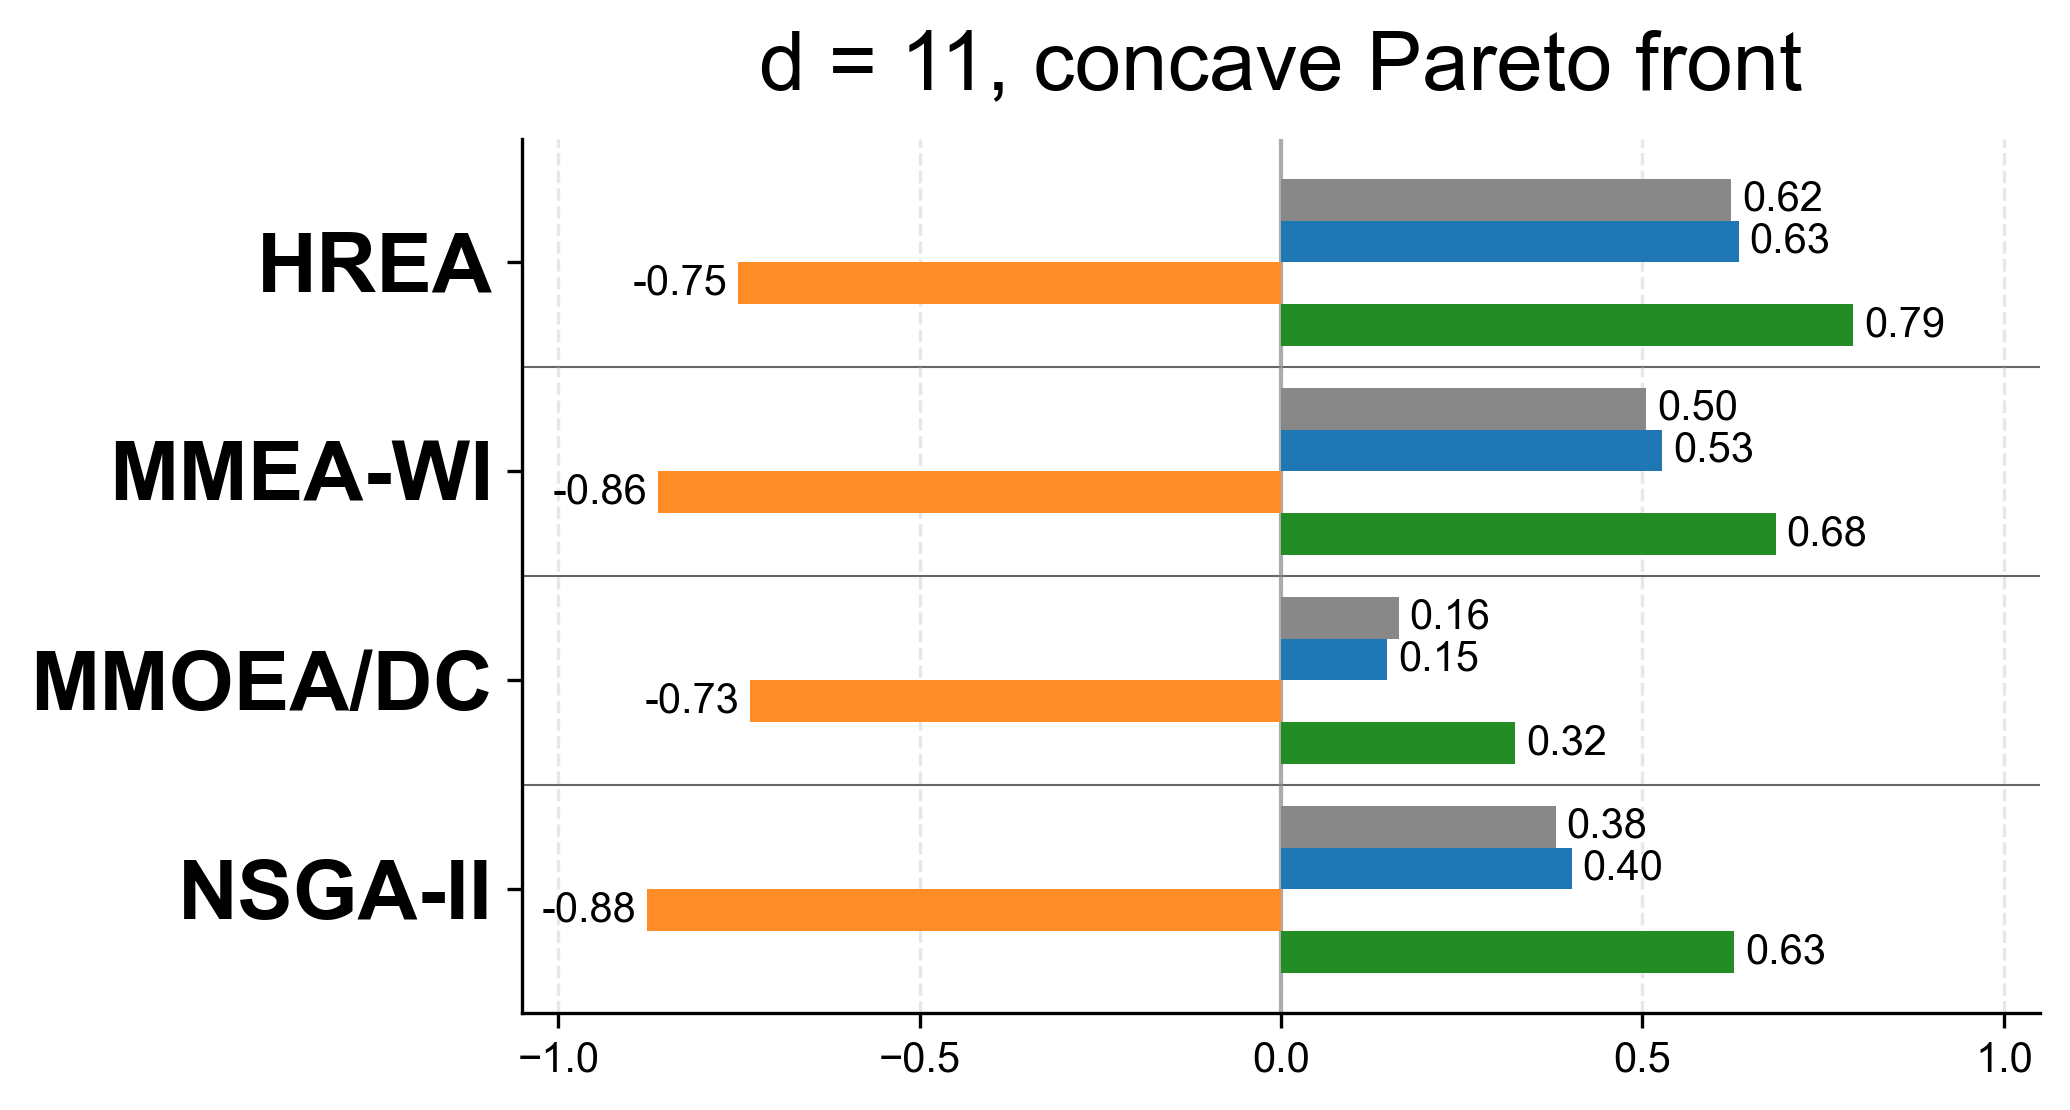

Saved: ..\spearman_score_concave_10d.svg


In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams
from scipy.stats import spearmanr
from pathlib import Path

rcParams["text.usetex"] = False
rcParams["font.family"] = "arial"
rcParams["mathtext.fontset"] = "cm"
rcParams["pdf.fonttype"] = 42
rcParams["ps.fonttype"] = 42
rcParams["figure.dpi"] = 300
rcParams["savefig.dpi"] = 300


for D in [2, 5, 10]:
    for score in ["rank", "score"]:
        for pf_shape in ["convex", "concave"]:
                        
            df = pd.read_csv(f"../platemo_average_{score}_{pf_shape}_{D}d.csv")


            features = ["num_epsilon_local_optima", "num_local_optima", "fdc", "disp_10pct"]
            feature_labels = {
                "num_epsilon_local_optima": "num_epsilon_local_optima", 
                "num_local_optima": "num_local_optima",
                "fdc": "fdc",
                "disp_10pct": "disp_10pct",
            }

            feature_colors = {
                "num_epsilon_local_optima": "#888888",
                "num_local_optima": "#1f77b4",
                "fdc":              "#ff8c27",
                "disp_10pct":       "#248c24",
            }

            algorithms = ["HREA", "MMEA-WI", "MMOEA/DC", "NSGA-II"]
            if score == "rank":
                algorithm_to_col = {
                    "HREA":     "IGDX_HREA_rank",
                    "MMEA-WI":  "IGDX_MMEAWI_rank",
                    "MMOEA/DC": "IGDX_MMOEADC_rank",
                    "NSGA-II":  "IGDX_NSGAII_rank",
                }
            else:
                algorithm_to_col = {
                    "HREA":     "IGDX_HREA",
                    "MMEA-WI":  "IGDX_MMEAWI",
                    "MMOEA/DC": "IGDX_MMOEADC",
                    "NSGA-II":  "IGDX_NSGAII",
                }


            rows = []
            for algo in algorithms:
                target_col = algorithm_to_col[algo]
                for feat in features:
                    rho, _ = spearmanr(df[feat], df[target_col])
                    rows.append({"algorithm": algo, "feature": feat, "rho": rho})

            corr_df = pd.DataFrame(rows)
            print(corr_df)


            n_algos = len(algorithms)
            n_feats = len(features)

            bar_height = 0.1
            group_height = bar_height * n_feats + 0.10  # tighter spacing

            y_positions = {}
            for i, algo in enumerate(algorithms):
                base = i * group_height
                for j, feat in enumerate(features):
                    y_positions[(algo, feat)] = base + j * bar_height

            fig, ax = plt.subplots(figsize=(7, 3.8))

            ax.axvline(0, color="#888888", linewidth=1.0, alpha=0.7, zorder=1)

            seen_features = set()
            for (algo, feat), y in y_positions.items():
                rho = corr_df.loc[
                    (corr_df["algorithm"] == algo) & (corr_df["feature"] == feat),
                    "rho",
                ].values[0]
                label = feature_labels[feat] if feat not in seen_features else None
                seen_features.add(feat)
                ax.barh(
                    y, rho,
                    height=bar_height,
                    color=feature_colors[feat],
                    edgecolor="none",
                    linewidth=0.5,
                    label=label,
                    zorder=2,
                )
                ha = "left" if rho >= 0 else "right"
                offset = 0.015 if rho >= 0 else -0.015
                ax.text(
                    rho + offset, y, f"{rho:.2f}",
                    va="center", ha=ha, fontsize=10,
                    zorder=3,
                )

            algo_centers = [np.mean([y_positions[(algo, feat)] for feat in features])
                            for algo in algorithms]
            ax.set_yticks(algo_centers)
            ax.set_yticklabels(algorithms, fontsize=20, fontweight="bold")

            for i in range(1, n_algos):
                sep_y = (algo_centers[i - 1] + algo_centers[i]) / 2
                ax.axhline(sep_y, color="black", linewidth=0.5, alpha=0.6, zorder=0)

            # Axis settings
            ax.set_xlim(-1.05, 1.05)
            ax.set_xticks(np.arange(-1.0, 1.01, 0.5))
            ax.invert_yaxis()

            ax.grid(axis="x", alpha=0.3, linestyle="--", zorder=0)

            for spine_name in ["top", "right"]:
                ax.spines[spine_name].set_visible(False)

            ax.set_title(f"d = {D+1}, {pf_shape} Pareto front", fontsize=20, pad=12)

            # # Legend below the plot
            # ax.legend(
            #     loc="upper center",
            #     bbox_to_anchor=(0.5, -0.20),
            #     ncol=3,
            #     fontsize=20,
            #     frameon=True,
            #     handlelength=1.5,
            #     handleheight=1.0,
            #     columnspacing=1.5,
            # )

            plt.tight_layout()

            output_path = Path(f"../spearman_{score}_{pf_shape}_{D}d.svg")
            plt.savefig(output_path, format="svg", bbox_inches="tight", transparent=True)
            plt.savefig(
                output_path.with_suffix(".png"),
                format="png", bbox_inches="tight", dpi=300,
            )
            plt.show()
            print(f"Saved: {output_path}")

# Regress the MMMO performance using random forest and run 31 trials of 10-fold cross validation

In [21]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
from sklearn.model_selection import KFold


def compute_feature_effects(
    df,
    feature_columns,
    model,
    output_csv="feature_effects.csv",
    n_splits=10,
    n_runs=31,
    random_state=42,
):
    target_columns = [
        column for column in df.columns
        if column.startswith("IGDX_") and not column.startswith("IGDX_Global")
    ]
    X = df[feature_columns].values
    rows = []

    for target_column in target_columns:
        print(f"Processing target: {target_column}")
        y = df[target_column].values

        for run in range(1, n_runs + 1):
            

            r2_scores = []
            coef_list = []

            kf = KFold(
                n_splits=n_splits,
                shuffle=True,
                random_state=random_state + run,
            )

            for train_idx, test_idx in kf.split(X):
                X_train, X_test = X[train_idx], X[test_idx]
                y_train, y_test = y[train_idx], y[test_idx]

                scaler = StandardScaler()
                X_train_scaled = scaler.fit_transform(X_train)
                X_test_scaled = scaler.transform(X_test)

                model.fit(X_train_scaled, y_train)
                predictions = model.predict(X_test_scaled)
                r2_scores.append(r2_score(y_test, predictions))

                if hasattr(model, "coef_"):
                    coef_list.append(model.coef_)
                else:
                    coef_list.append(model.feature_importances_)

            coef_array = np.array(coef_list)

            row = {
                "target": target_column,
                "run": run,
                "r2_mean": np.mean(r2_scores), 
                "r2_std": np.std(r2_scores),
            }
            row.update({
                feature_name: coef_array[:, i].mean()
                for i, feature_name in enumerate(feature_columns)
            })
            rows.append(row)
            print(f"Processing run: {run}", f"R2 mean: {row['r2_mean']:.4f}")

    result_df = pd.DataFrame(rows)
    result_df.to_csv(output_csv, index=False)
    return result_df

In [23]:
from sklearn.ensemble import RandomForestRegressor
import pandas as pd
import matplotlib as mpl
mpl.rcParams["axes.labelpad"] = 10

for D in [2, 5, 10]:
    for score in ["score", "rank"]:
        for pf_shape in ["convex", "concave"]:
                    
            average_table = pd.read_csv(
                f"../platemo_average_{score}_{pf_shape}_{D}d.csv"
            )
                    
            model = RandomForestRegressor(
                n_estimators=1,
                max_depth=2,
                random_state=42,
            )

            results = compute_feature_effects(
                df=average_table,
                feature_columns=[
                    "num_local_optima",
                    "fdc",
                    "disp_10pct",
                ],
                model=model,
                output_csv=f"../regression_res/tree_regression_results_{score}_{pf_shape}_{D}d.csv",
                n_splits=10,
                n_runs=31,
                random_state=42,
            )

            print(results)

Processing target: IGDX_HREA
Processing run: 1 R2 mean: 0.7725
Processing run: 2 R2 mean: 0.7713
Processing run: 3 R2 mean: 0.7675
Processing run: 4 R2 mean: 0.7695
Processing run: 5 R2 mean: 0.7700
Processing run: 6 R2 mean: 0.7657
Processing run: 7 R2 mean: 0.7702
Processing run: 8 R2 mean: 0.7646
Processing run: 9 R2 mean: 0.7729
Processing run: 10 R2 mean: 0.7697
Processing run: 11 R2 mean: 0.7695
Processing run: 12 R2 mean: 0.7676
Processing run: 13 R2 mean: 0.7659
Processing run: 14 R2 mean: 0.7713
Processing run: 15 R2 mean: 0.7728
Processing run: 16 R2 mean: 0.7736
Processing run: 17 R2 mean: 0.7642
Processing run: 18 R2 mean: 0.7646
Processing run: 19 R2 mean: 0.7736
Processing run: 20 R2 mean: 0.7734
Processing run: 21 R2 mean: 0.7705
Processing run: 22 R2 mean: 0.7667
Processing run: 23 R2 mean: 0.7663
Processing run: 24 R2 mean: 0.7719
Processing run: 25 R2 mean: 0.7667
Processing run: 26 R2 mean: 0.7717
Processing run: 27 R2 mean: 0.7675
Processing run: 28 R2 mean: 0.7669


In [24]:
for D in [2, 5, 10]:
    for score in ["score", "rank"]:
        for pf_shape in ["convex", "concave"]:

            csv_path = f'../regression_res/platemo_regression_results_{score}_{pf_shape}_{D}d.csv'
            df = pd.read_csv(csv_path)

            df['algorithm'] = df['target'].str.replace('IGDX_', '', regex=False)

            order = (
                df.groupby('algorithm')['r2_mean']
                .median()
                .sort_values(ascending=False)
                .index
                .tolist()
            )

            summary = (
                df.groupby('algorithm')['r2_mean']
                .agg(['mean', 'std'])
                .loc[order]
                .round(4)
            )
            
            summary.to_csv(
                f'../regression_res/platemo_regression_summary_{score}_{pf_shape}_{D}d.csv'
            )

In [25]:
import pandas as pd

DECIMALS = 3

ALGO_ORDER = ["HREA", "MMEA-WI", "MMOEA/DC", "NSGA-II"]

DISPLAY_TO_RAW = {
    "HREA": "HREA",
    "MMEA-WI": "MMEAWI",
    "MMOEA/DC": "MMOEADC",
    "NSGA-II": "NSGAII",
}


def fmt(m, s):
    return f"{m:.{DECIMALS}f} ({s:.{DECIMALS}f})"


for score in ["score", "rank"]:
    for pf_shape in ["convex", "concave"]:
        df_2d = pd.read_csv(f"../regression_res/platemo_regression_summary_{score}_{pf_shape}_2d.csv")
        df_5d = pd.read_csv(f"../regression_res/platemo_regression_summary_{score}_{pf_shape}_5d.csv")
        df_10d = pd.read_csv(f"../regression_res/platemo_regression_summary_{score}_{pf_shape}_10d.csv")

        rows = []
        for display in ALGO_ORDER:
            if score == "rank":
                raw_algo = f"{DISPLAY_TO_RAW[display]}_{score}"  
            else:
                raw_algo = f"{DISPLAY_TO_RAW[display]}" 
            print(f"Processing algorithm: {display} (raw: {raw_algo})")
            row = {"algorithm": display}
            for d_label, df_d in [("d = 2", df_2d), ("d = 5", df_5d), ("d = 10", df_10d)]:
                m = df_d.loc[df_d["algorithm"] == raw_algo, "mean"].values[0]
                s = df_d.loc[df_d["algorithm"] == raw_algo, "std"].values[0]
                row[d_label] = fmt(m, s)
            rows.append(row)

        result = pd.DataFrame(rows)
        result.to_csv(
            f"../regression_res/platemo_regression_table_{score}_{pf_shape}.csv",
            index=False,
        )
        print(f"[{score}]")
        print(result, end="\n\n")

Processing algorithm: HREA (raw: HREA)
Processing algorithm: MMEA-WI (raw: MMEAWI)
Processing algorithm: MMOEA/DC (raw: MMOEADC)
Processing algorithm: NSGA-II (raw: NSGAII)
[score]
  algorithm          d = 2          d = 5         d = 10
0      HREA  0.882 (0.001)  0.936 (0.001)  0.972 (0.001)
1   MMEA-WI  0.943 (0.001)  0.970 (0.001)  0.970 (0.001)
2  MMOEA/DC  0.920 (0.002)  0.950 (0.001)  0.962 (0.002)
3   NSGA-II  0.979 (0.001)  0.975 (0.001)  0.970 (0.002)

Processing algorithm: HREA (raw: HREA)
Processing algorithm: MMEA-WI (raw: MMEAWI)
Processing algorithm: MMOEA/DC (raw: MMOEADC)
Processing algorithm: NSGA-II (raw: NSGAII)
[score]
  algorithm          d = 2          d = 5         d = 10
0      HREA  0.861 (0.003)  0.951 (0.001)  0.979 (0.001)
1   MMEA-WI  0.943 (0.001)  0.970 (0.001)  0.968 (0.001)
2  MMOEA/DC  0.915 (0.002)  0.941 (0.001)  0.962 (0.002)
3   NSGA-II  0.978 (0.001)  0.973 (0.001)  0.969 (0.002)

Processing algorithm: HREA (raw: HREA_rank)
Processing algorithm: 

In [26]:

def csv_to_latex(csv_path: Path, caption: str, label: str) -> str:
    df = pd.read_csv(csv_path, skipinitialspace=True)

    algo_col = df.columns[0]
    metric_cols = list(df.columns[1:])
    header_labels = [c.strip().upper() for c in metric_cols]

    rows = []
    for _, row in df.iterrows():
        algo = str(row[algo_col])
        cells = [str(row[c]) for c in metric_cols]
        rows.append((algo, cells))

    col_spec = "l" + "c" * len(metric_cols)

    lines = []
    lines.append(r"\begin{table*}[tb]")
    lines.append(r"  \centering")
    lines.append(rf"  \caption{{{caption}}}")
    lines.append(rf"  \label{{{label}}}")
    lines.append(rf"  \begin{{tabular}}{{{col_spec}}}")
    lines.append(r"    \toprule")
    lines.append("    " + " & ".join(["Algorithm"] + header_labels) + r" \\")
    lines.append(r"    \midrule")
    for algo, cells in rows:
        lines.append("    " + " & ".join([algo] + cells) + r" \\")
    lines.append(r"    \bottomrule")
    lines.append(r"  \end{tabular}")
    lines.append(r"\end{table*}")
    return "\n".join(lines)


for score in ["score", "rank"]:
    for pf_shape in ["convex", "concave"]:
        csv_path = Path(f"../regression_res/platemo_regression_table_{score}_{pf_shape}.csv")
        caption = f"{pf_shape.capitalize()} Pareto Front - {score.capitalize()}"
        label = f"tab:platemo_{score}_{pf_shape}"
        latex_code = csv_to_latex(csv_path, caption, label)
        print(latex_code)

\begin{table*}[tb]
  \centering
  \caption{Convex Pareto Front - Score}
  \label{tab:platemo_score_convex}
  \begin{tabular}{lccc}
    \toprule
    Algorithm & D = 2 & D = 5 & D = 10 \\
    \midrule
    HREA & 0.882 (0.001) & 0.936 (0.001) & 0.972 (0.001) \\
    MMEA-WI & 0.943 (0.001) & 0.970 (0.001) & 0.970 (0.001) \\
    MMOEA/DC & 0.920 (0.002) & 0.950 (0.001) & 0.962 (0.002) \\
    NSGA-II & 0.979 (0.001) & 0.975 (0.001) & 0.970 (0.002) \\
    \bottomrule
  \end{tabular}
\end{table*}
\begin{table*}[tb]
  \centering
  \caption{Concave Pareto Front - Score}
  \label{tab:platemo_score_concave}
  \begin{tabular}{lccc}
    \toprule
    Algorithm & D = 2 & D = 5 & D = 10 \\
    \midrule
    HREA & 0.861 (0.003) & 0.951 (0.001) & 0.979 (0.001) \\
    MMEA-WI & 0.943 (0.001) & 0.970 (0.001) & 0.968 (0.001) \\
    MMOEA/DC & 0.915 (0.002) & 0.941 (0.001) & 0.962 (0.002) \\
    NSGA-II & 0.978 (0.001) & 0.973 (0.001) & 0.969 (0.002) \\
    \bottomrule
  \end{tabular}
\end{table*}
\begin{tab

# Compare the distribution of MSG landscapes and BBOB instances on FDC-Dispersion space. 

In [27]:
import sys
sys.path.insert(0, r"C:\mmmo-algorithm-selection")

import numpy as np
import pandas as pd
import torch
import cocoex

from x_msg.extract_features import (
    compute_distances_to_global,
    compute_dispersion_features,
    extract_fdc_feature,
)
from x_msg.sampling import sobol_sampling


device = "cuda" if torch.cuda.is_available() else "cpu"
base_seed = 42

for D in [2, 5, 10]:

    num_samples = D * 500

    rows = []
    for fid in range(1, 25):
        for iid in range(1, 11):

            fdc_list = []
            dispersion_list = []

            for run in range(1, 11):
                    
                seed = base_seed + run

                X = sobol_sampling(D, num_samples=num_samples, device=device, seed=seed)
                X_np = np.asarray(X.detach().cpu().numpy(), dtype=np.float64)
                X_scaled = X_np * 10 - 5

                problem = cocoex.BareProblem("bbob", function=fid, dimension=D, instance=iid)

                y = np.array([problem(x) for x in X_scaled])
                from scipy.stats import rankdata

                y_norm = rankdata(y) / len(y) 
                y_tensor = torch.tensor(y_norm, dtype=torch.float32, device=device)
                Y = y_tensor.reshape(1, num_samples)

                x_opt = problem.best_parameter()
                x_opt_tensor = torch.tensor(x_opt, dtype=torch.float32, device=device)
                distance = compute_distances_to_global(X, x_opt_tensor.reshape(1, -1))

                fdc = extract_fdc_feature(distance, Y)["fdc"]
                disp = compute_dispersion_features(X, Y)["disp_10pct"]

                fdc_list.append(fdc.detach().cpu().numpy())
                dispersion_list.append(disp.detach().cpu().numpy())


            rows.append({
                "function_id": fid,
                "instance_id": iid,
                "fdc":        float(np.mean(fdc_list)),
                "dispersion": float(disp.detach().cpu().numpy()),
            })

            print(f"f{fid} i{iid}: fdc={rows[-1]['fdc']:.4f}, disp={rows[-1]['dispersion']:.4f}")

df = pd.DataFrame(rows, columns=["function_id", "instance_id", "fdc", "dispersion"])
df.to_csv(f"bbob_features_D{D}.csv", index=False)
print(f"Saved: bbob_features_D{D}.csv  (shape={df.shape})")

f1 i1: fdc=0.5077, disp=0.1649
f1 i2: fdc=0.9492, disp=0.1641
f1 i3: fdc=0.9076, disp=0.1673
f1 i4: fdc=0.5562, disp=0.1628
f1 i5: fdc=0.9039, disp=0.1643
f1 i6: fdc=0.8806, disp=0.1644
f1 i7: fdc=0.1418, disp=0.1624
f1 i8: fdc=0.9097, disp=0.1639
f1 i9: fdc=0.8877, disp=0.1625
f1 i10: fdc=0.7137, disp=0.1634
f2 i1: fdc=0.1659, disp=0.3445
f2 i2: fdc=0.8869, disp=0.3425
f2 i3: fdc=0.9747, disp=0.3449
f2 i4: fdc=0.8109, disp=0.3470
f2 i5: fdc=0.9885, disp=0.3396
f2 i6: fdc=0.2905, disp=0.3431
f2 i7: fdc=0.4361, disp=0.3368
f2 i8: fdc=0.1139, disp=0.3396
f2 i9: fdc=0.0375, disp=0.3367
f2 i10: fdc=0.4360, disp=0.3396
f3 i1: fdc=0.5696, disp=0.2390
f3 i2: fdc=0.4578, disp=0.2339
f3 i3: fdc=0.4296, disp=0.2497
f3 i4: fdc=0.7303, disp=0.2217
f3 i5: fdc=0.3645, disp=0.2240
f3 i6: fdc=0.7789, disp=0.2458
f3 i7: fdc=0.8270, disp=0.2697
f3 i8: fdc=0.4135, disp=0.2539
f3 i9: fdc=0.9842, disp=0.2698
f3 i10: fdc=0.5005, disp=0.2296
f4 i1: fdc=0.2832, disp=0.2080
f4 i2: fdc=-0.0155, disp=0.2098
f4 i

In [28]:
import pandas as pd

for D in [2, 5, 10]:

    df = pd.read_csv(f"../platemo_average_score_convex_{D}d.csv")

    function_ids = df["function_id"]
    instance_ids = df["instance_id"]
    num_local_optima = df["num_local_optima"]
    fdc = df["fdc"]
    dispersion = df["disp_10pct"]

    df = pd.DataFrame({
        "function_id": function_ids,
        "instance_id": instance_ids,
        "num_local_optima": num_local_optima,
        "fdc": fdc,
        "dispersion": dispersion
    })

    df.to_csv(f"msg_features_D{D}.csv", index=False)
    print(f"Saved: msg_features_D{D}.csv  (shape={df.shape})")

Saved: msg_features_D2.csv  (shape=(1600, 5))
Saved: msg_features_D5.csv  (shape=(1600, 5))
Saved: msg_features_D10.csv  (shape=(1600, 5))


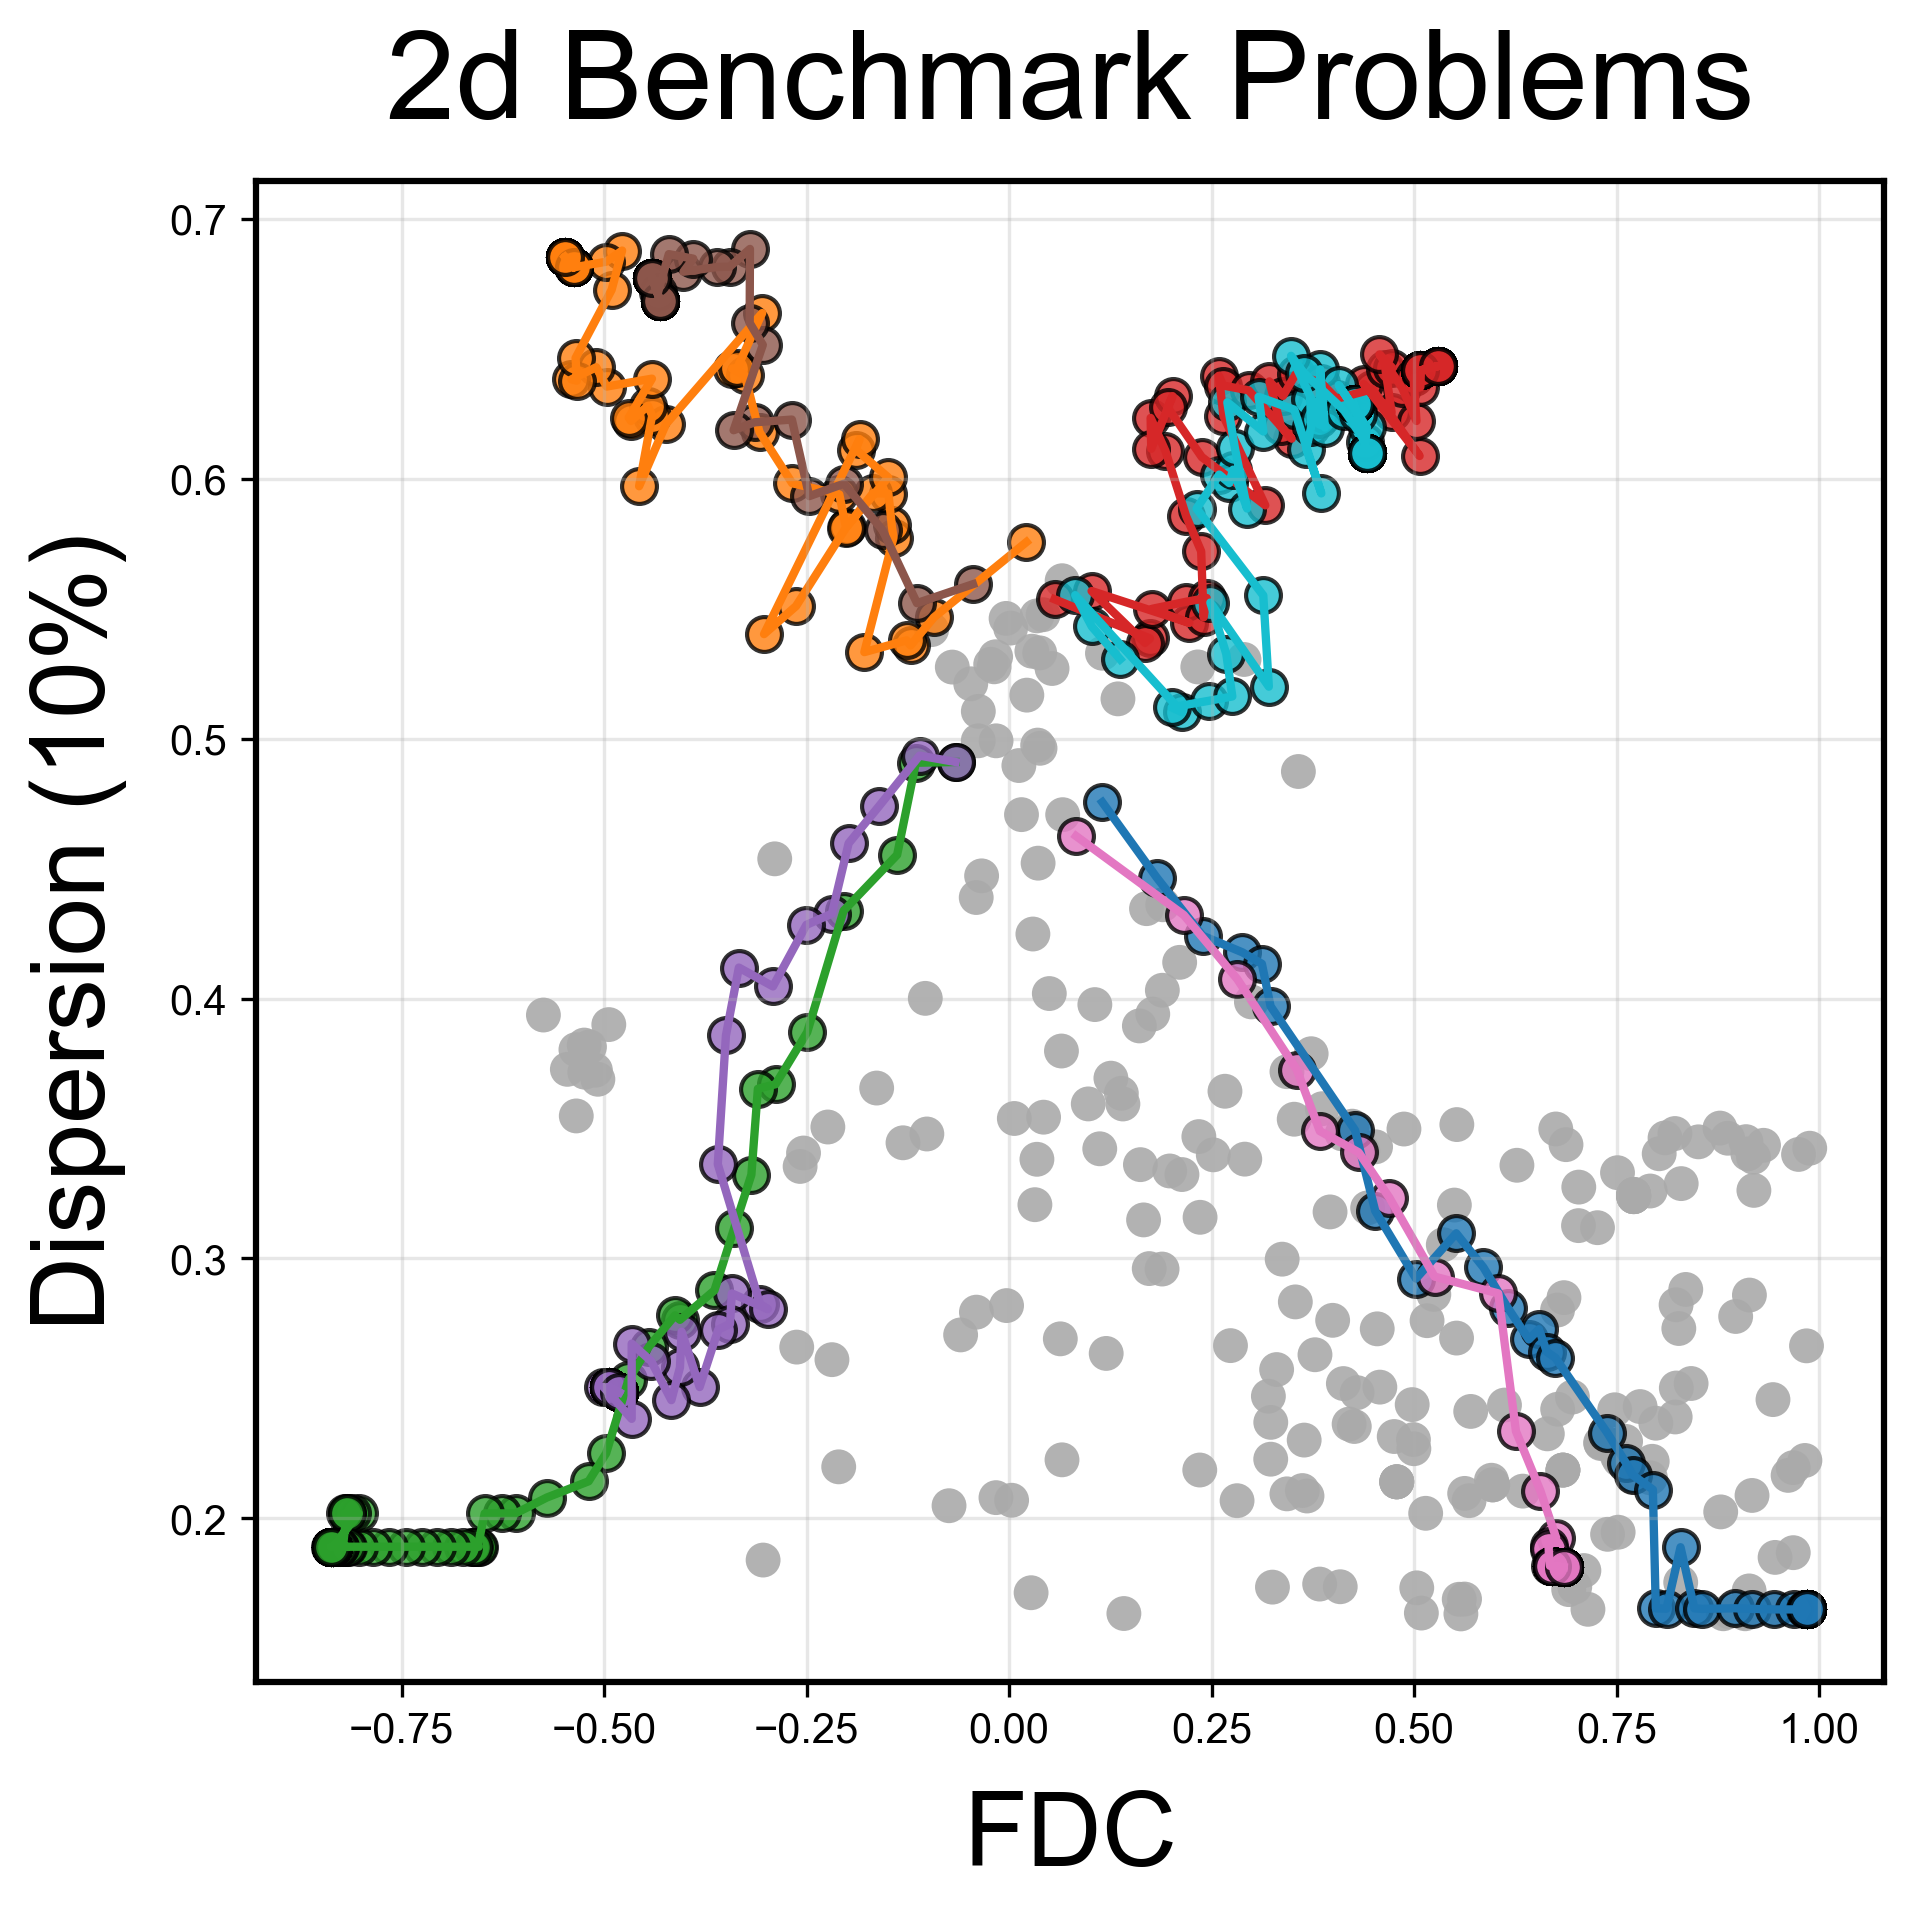

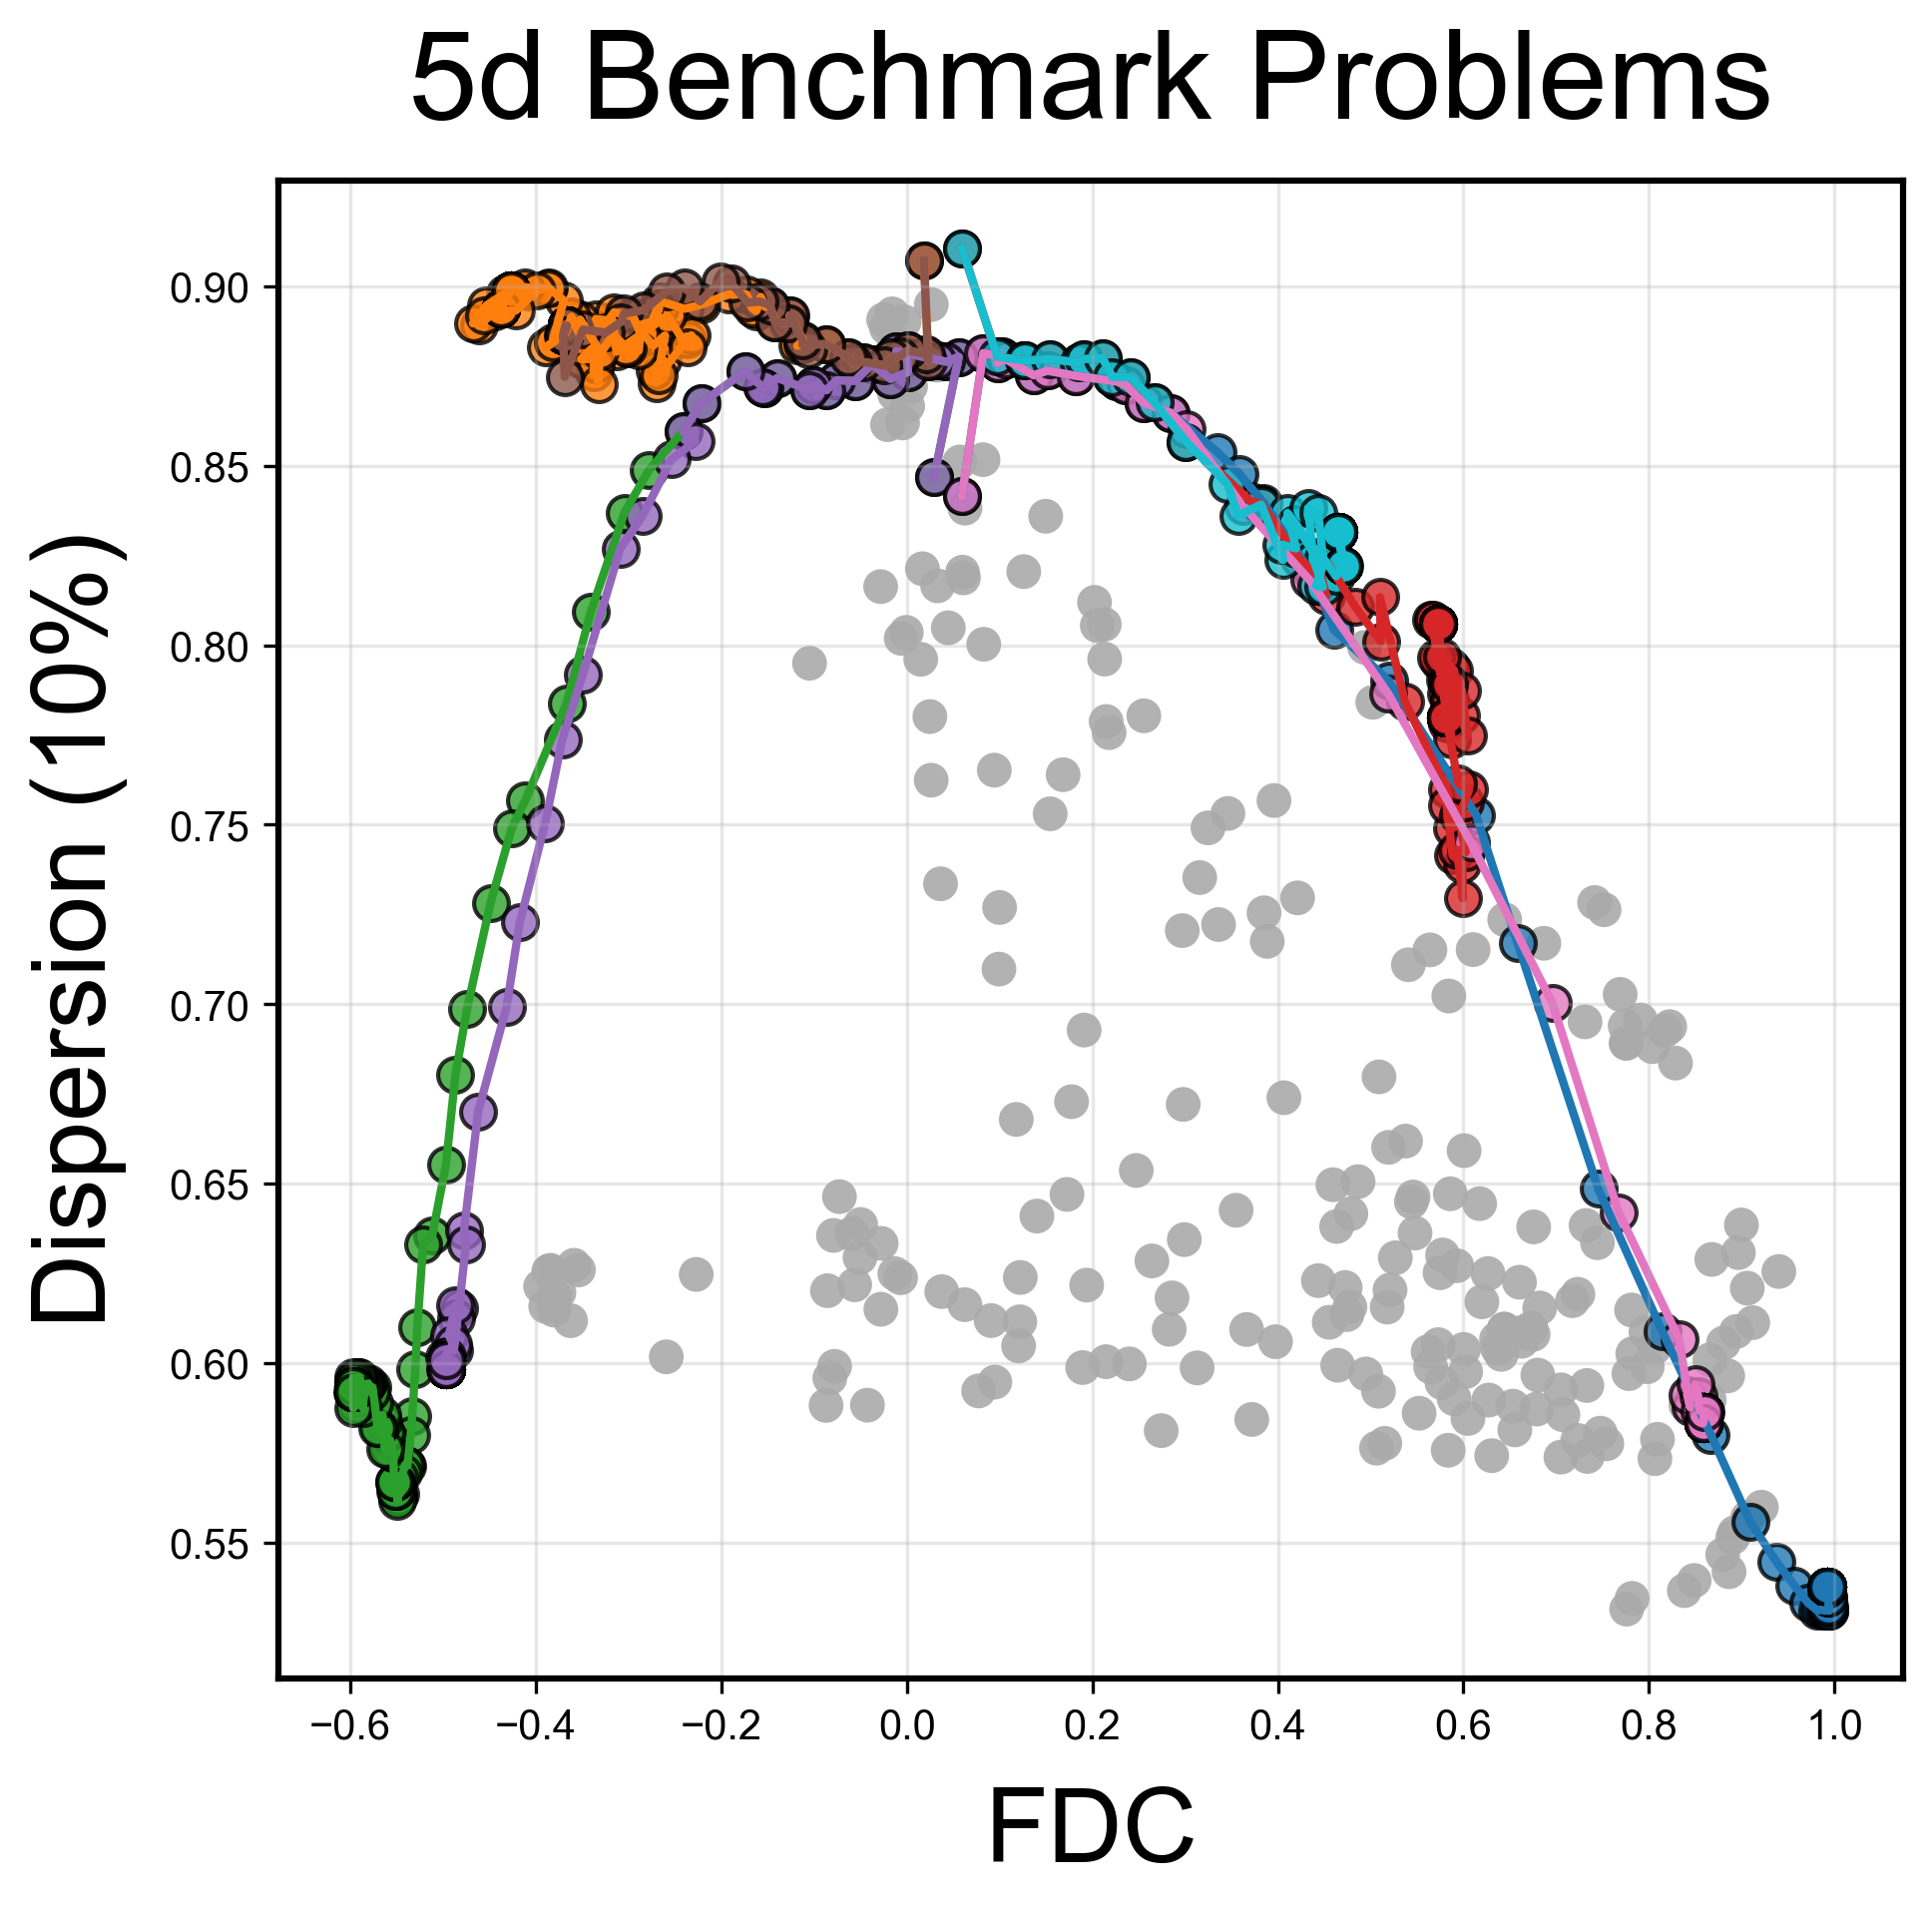

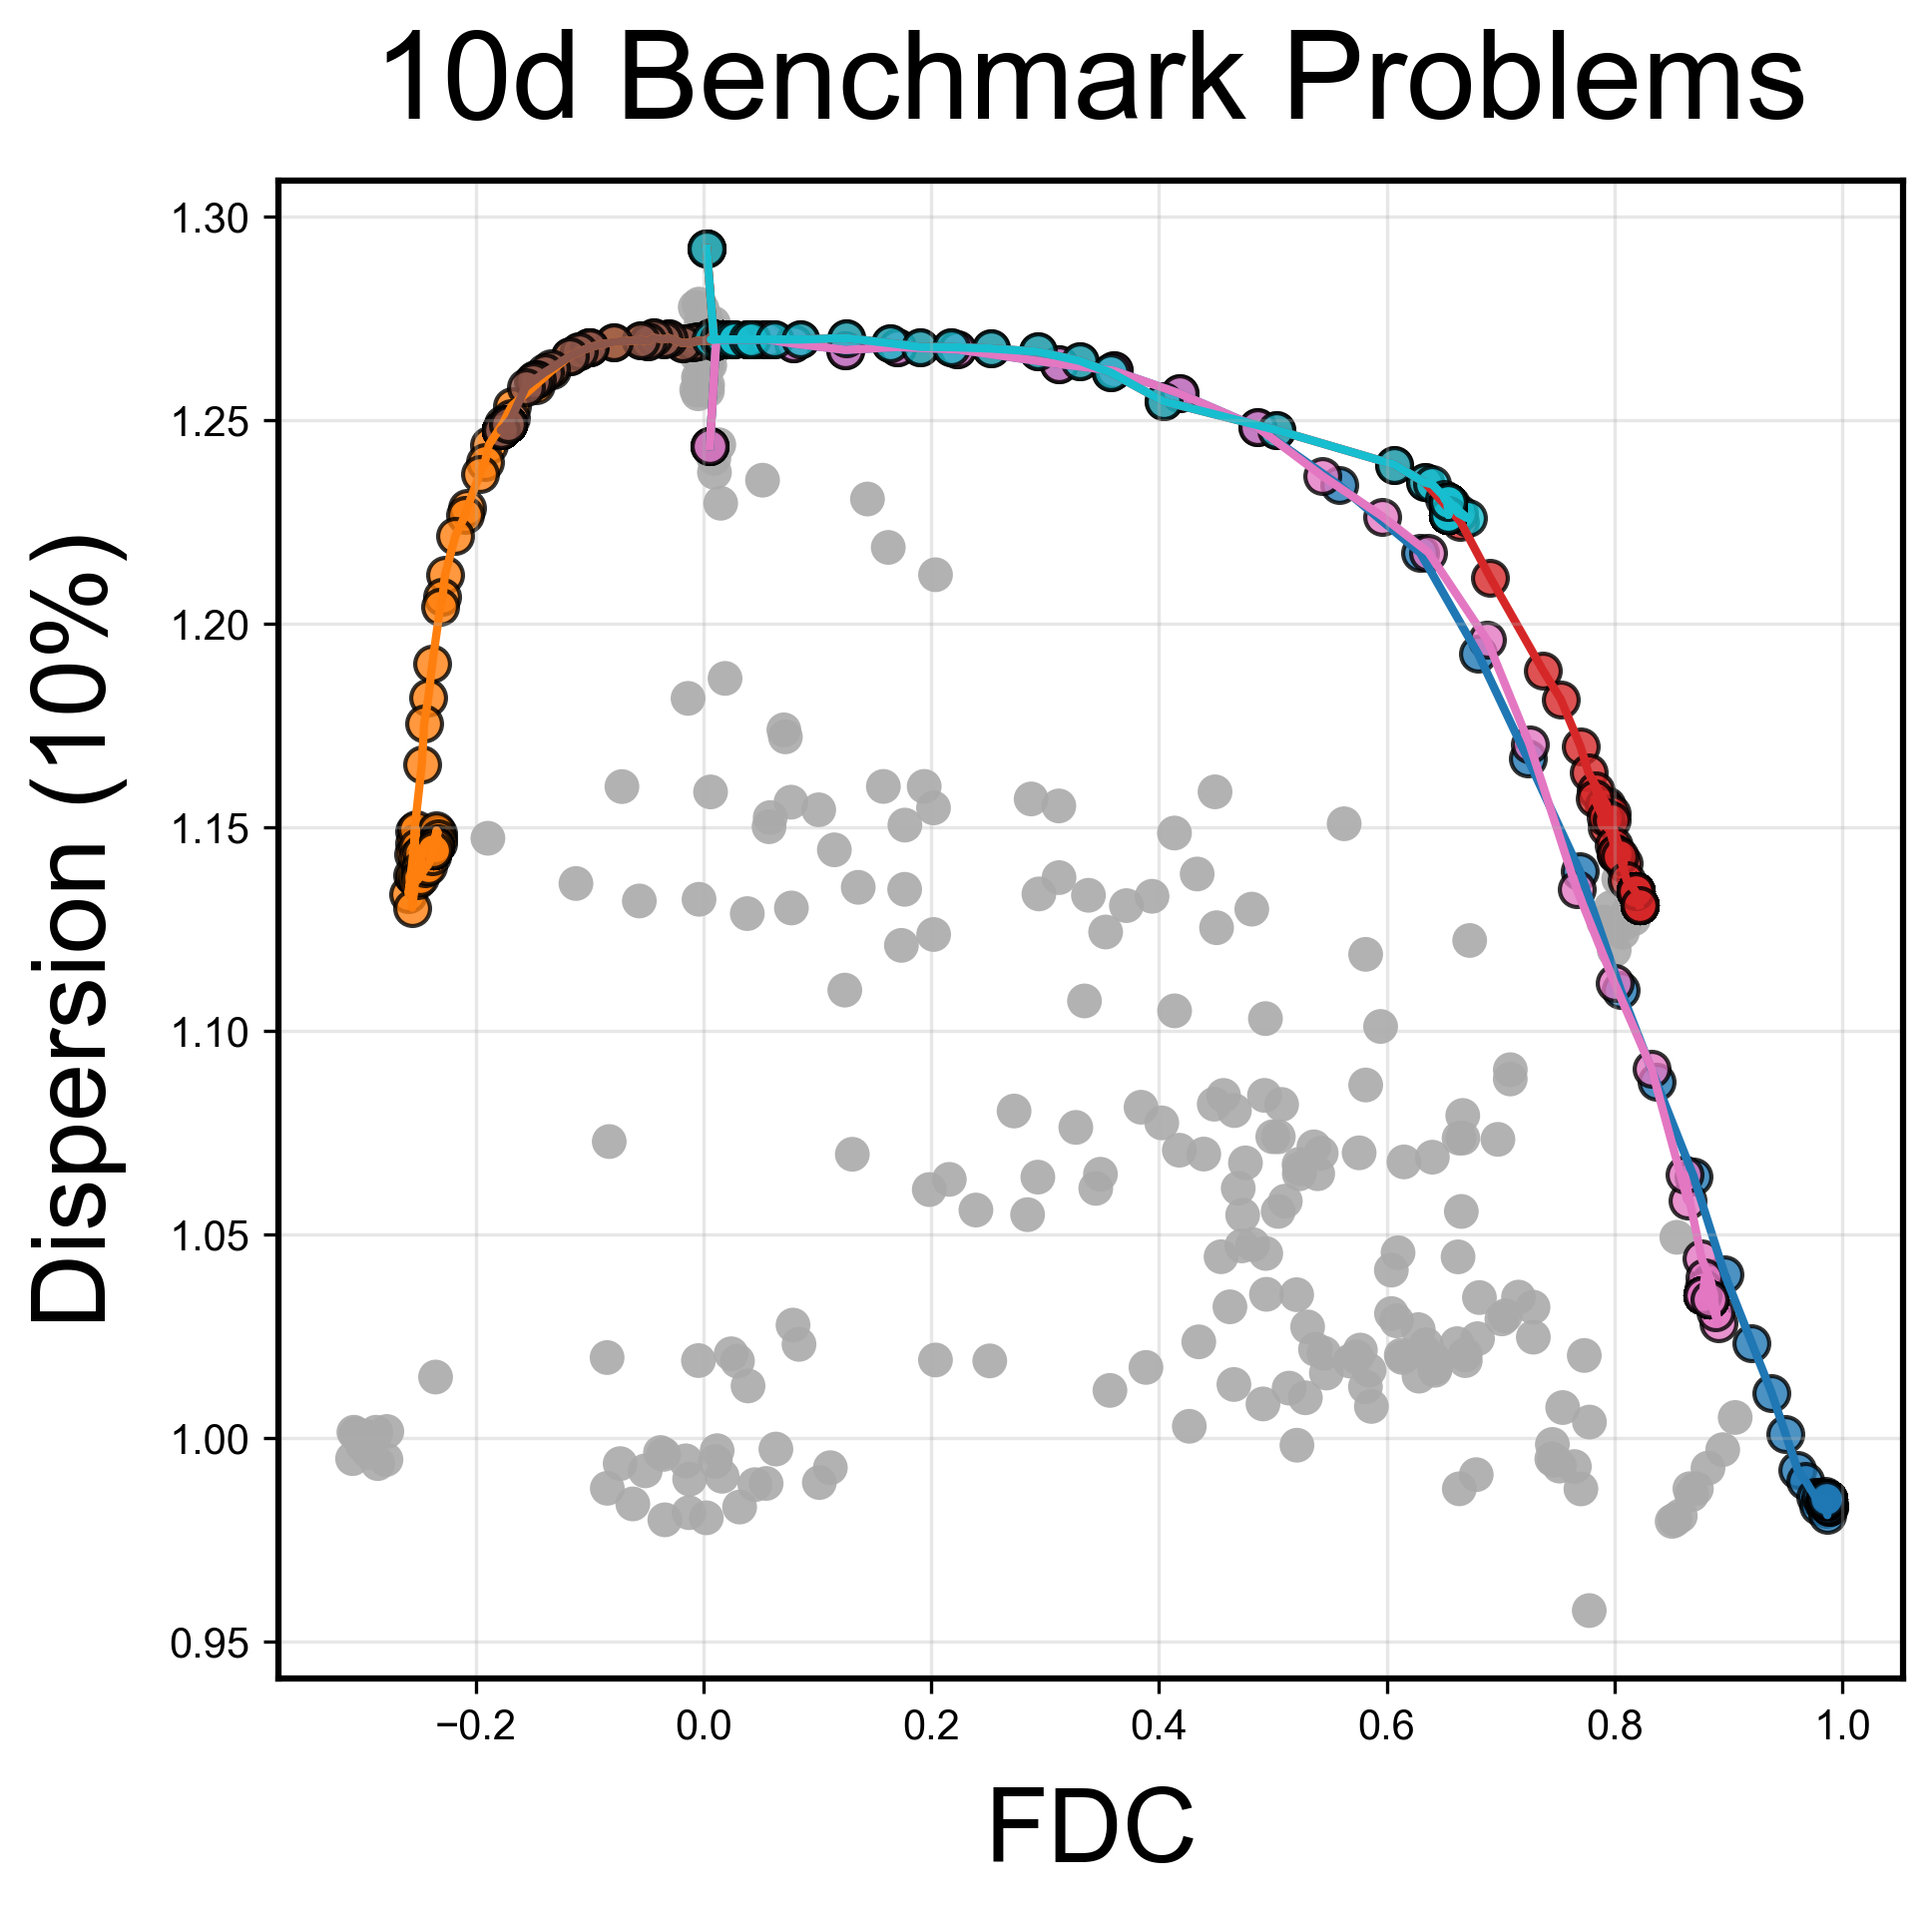

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
from pathlib import Path

rcParams["text.usetex"] = False
rcParams["font.family"] = "arial"
rcParams["mathtext.fontset"] = "cm"
rcParams["pdf.fonttype"] = 42
rcParams["ps.fonttype"] = 42
rcParams["figure.dpi"] = 300
rcParams["savefig.dpi"] = 300

for D in [2, 5, 10]:
        
    bbob = pd.read_csv(f"bbob_features_D{D}.csv")
    platemo = pd.read_csv(f"platemo_features_D{D}.csv")


    bbob_color = "#aaaaaa"

    category_colors = {
        "010": "#1f77b4",
        "001": "#ff7f0e",
        "000": "#2ca02c",
        "011": "#d62728",
        "100": "#9467bd",
        "101": "#8c564b",
        "110": "#e377c2",
        "111": "#17becf",
    }
    category_labels = {
        "000": "min_min_min",
        "001": "min_min_max",
        "010": "min_max_min",
        "011": "min_max_max",
        "100": "max_min_min",
        "101": "max_min_max",
        "110": "max_max_min",
        "111": "max_max_max",
    }

    fig, ax = plt.subplots(figsize=(7, 6.5))


    ax.scatter(
        bbob["fdc"],
        bbob["dispersion"],
        c=bbob_color,
        s=70,
        alpha=0.9,
        edgecolor="none",
        label="BBOB",
    )


    for fid in category_colors:
        sub = platemo[platemo["function_id"] == int(fid)]
        ax.scatter(
            sub["fdc"],
            sub["dispersion"],
            c=category_colors[fid],
            s=70,
            alpha=0.8,
            edgecolor="k",
            linewidth=1,
            label=category_labels[fid],
        )

    if "instance_id" in platemo.columns:
        for fid in category_colors:
            sub = platemo[platemo["function_id"] == int(fid)].sort_values("instance_id")
            ax.plot(
                sub["fdc"],
                sub["dispersion"],
                color=category_colors[fid],
                linewidth=2,
                alpha=1.0,
                zorder=1,
            )

    ax.set_xlabel("FDC", fontsize=25)
    ax.set_ylabel("Dispersion (10%)", fontsize=25)
    ax.set_title(rf"{D}d Benchmark Problems", fontsize=30, pad=15)
    ax.grid(alpha=0.3)

    for spine in ax.spines.values():
        spine.set_linewidth(1.5)

    output_path = Path(f"scatter_fdc_disp_{D}d.svg")
    plt.savefig(output_path, format="svg", bbox_inches="tight", transparent=True)
    plt.show()

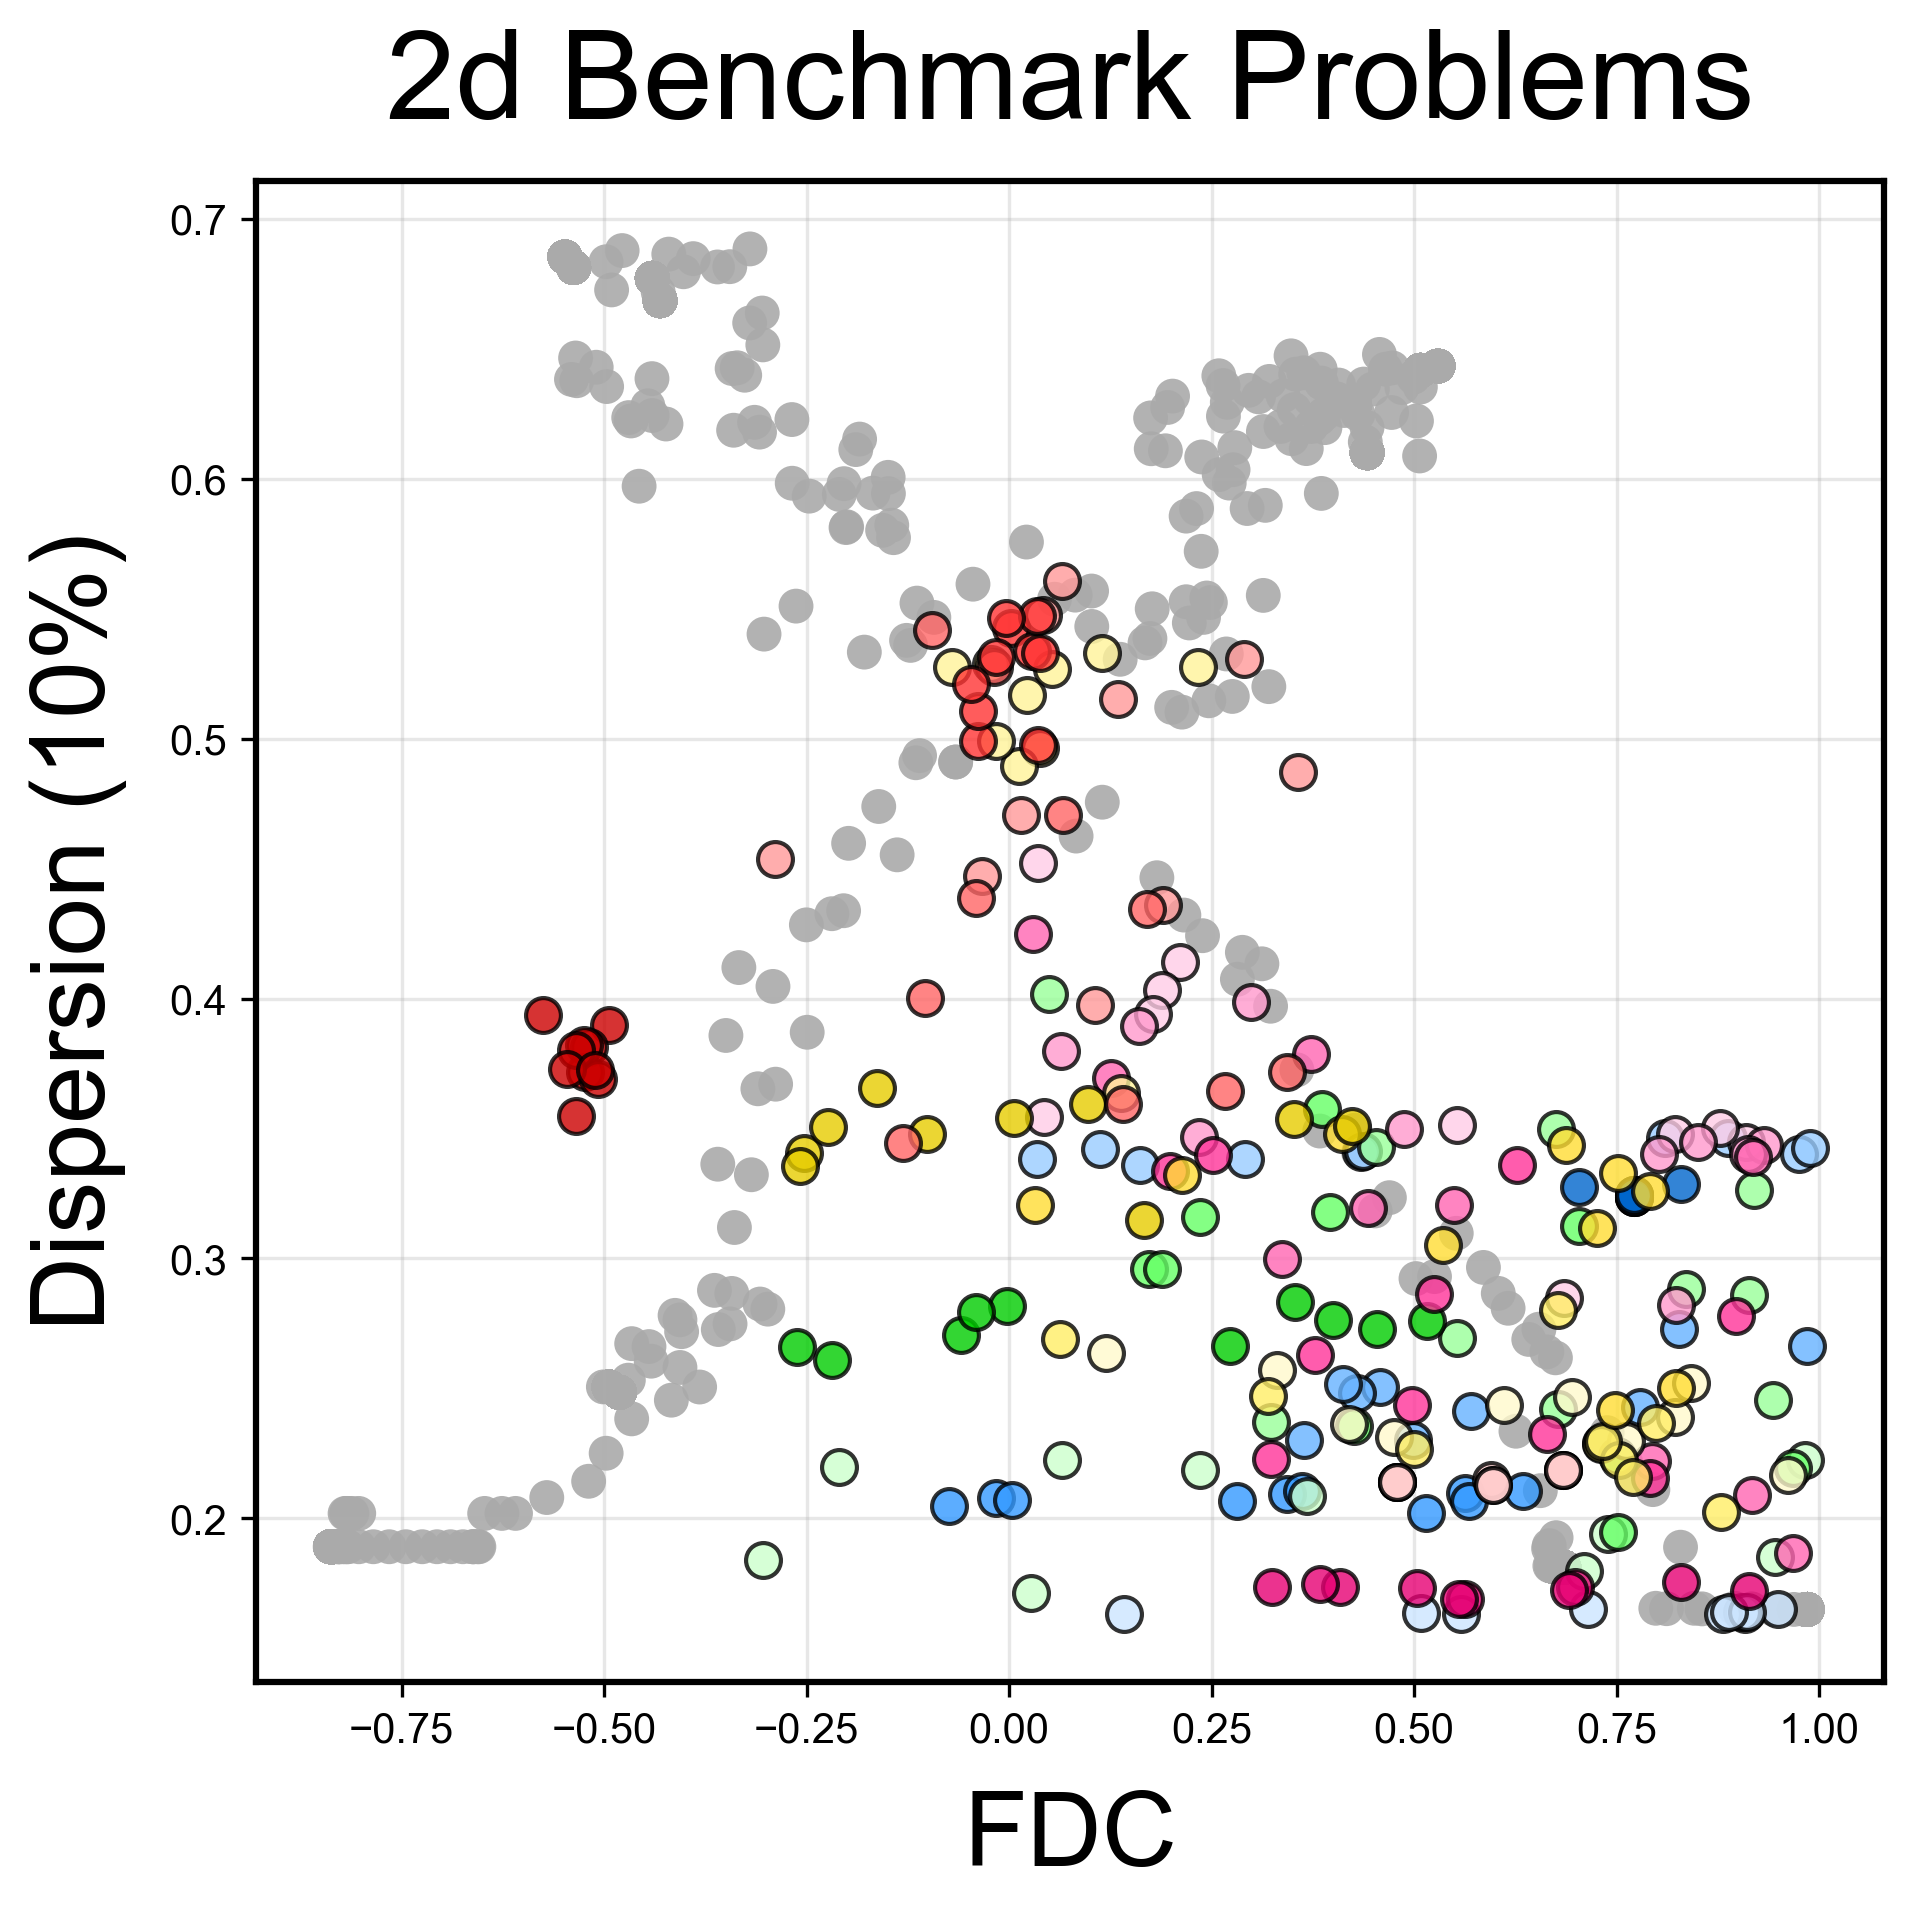

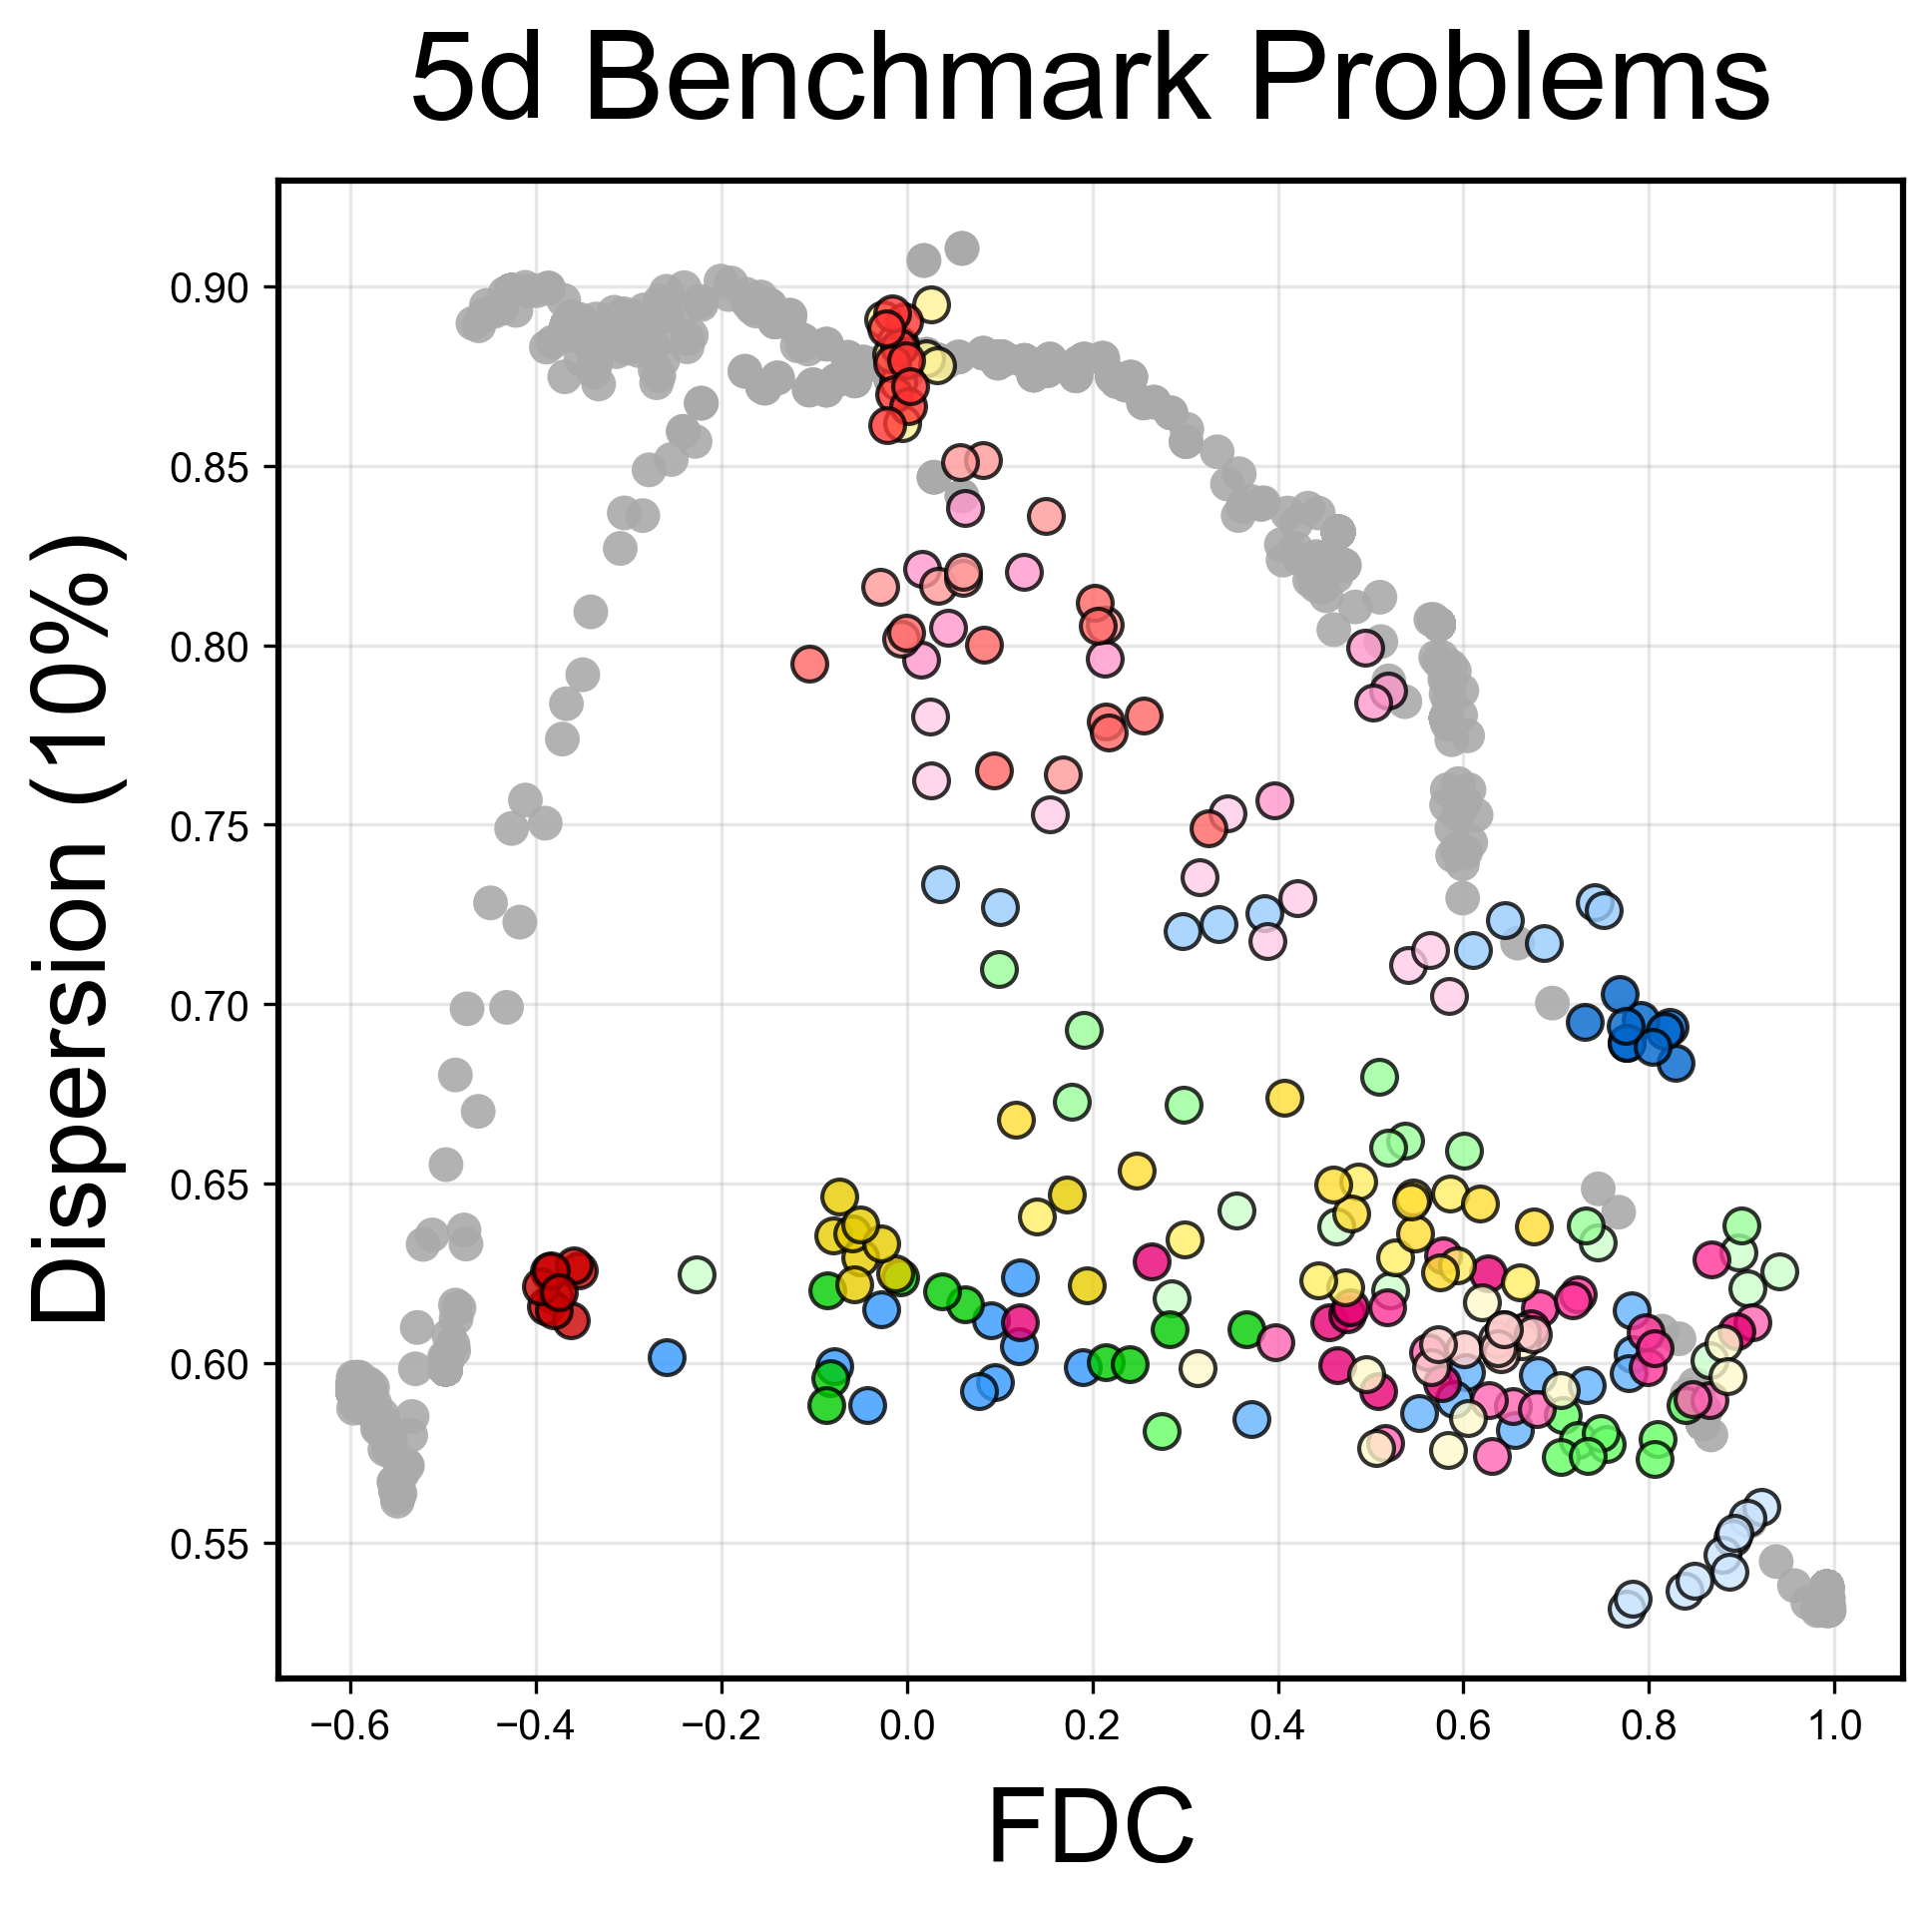

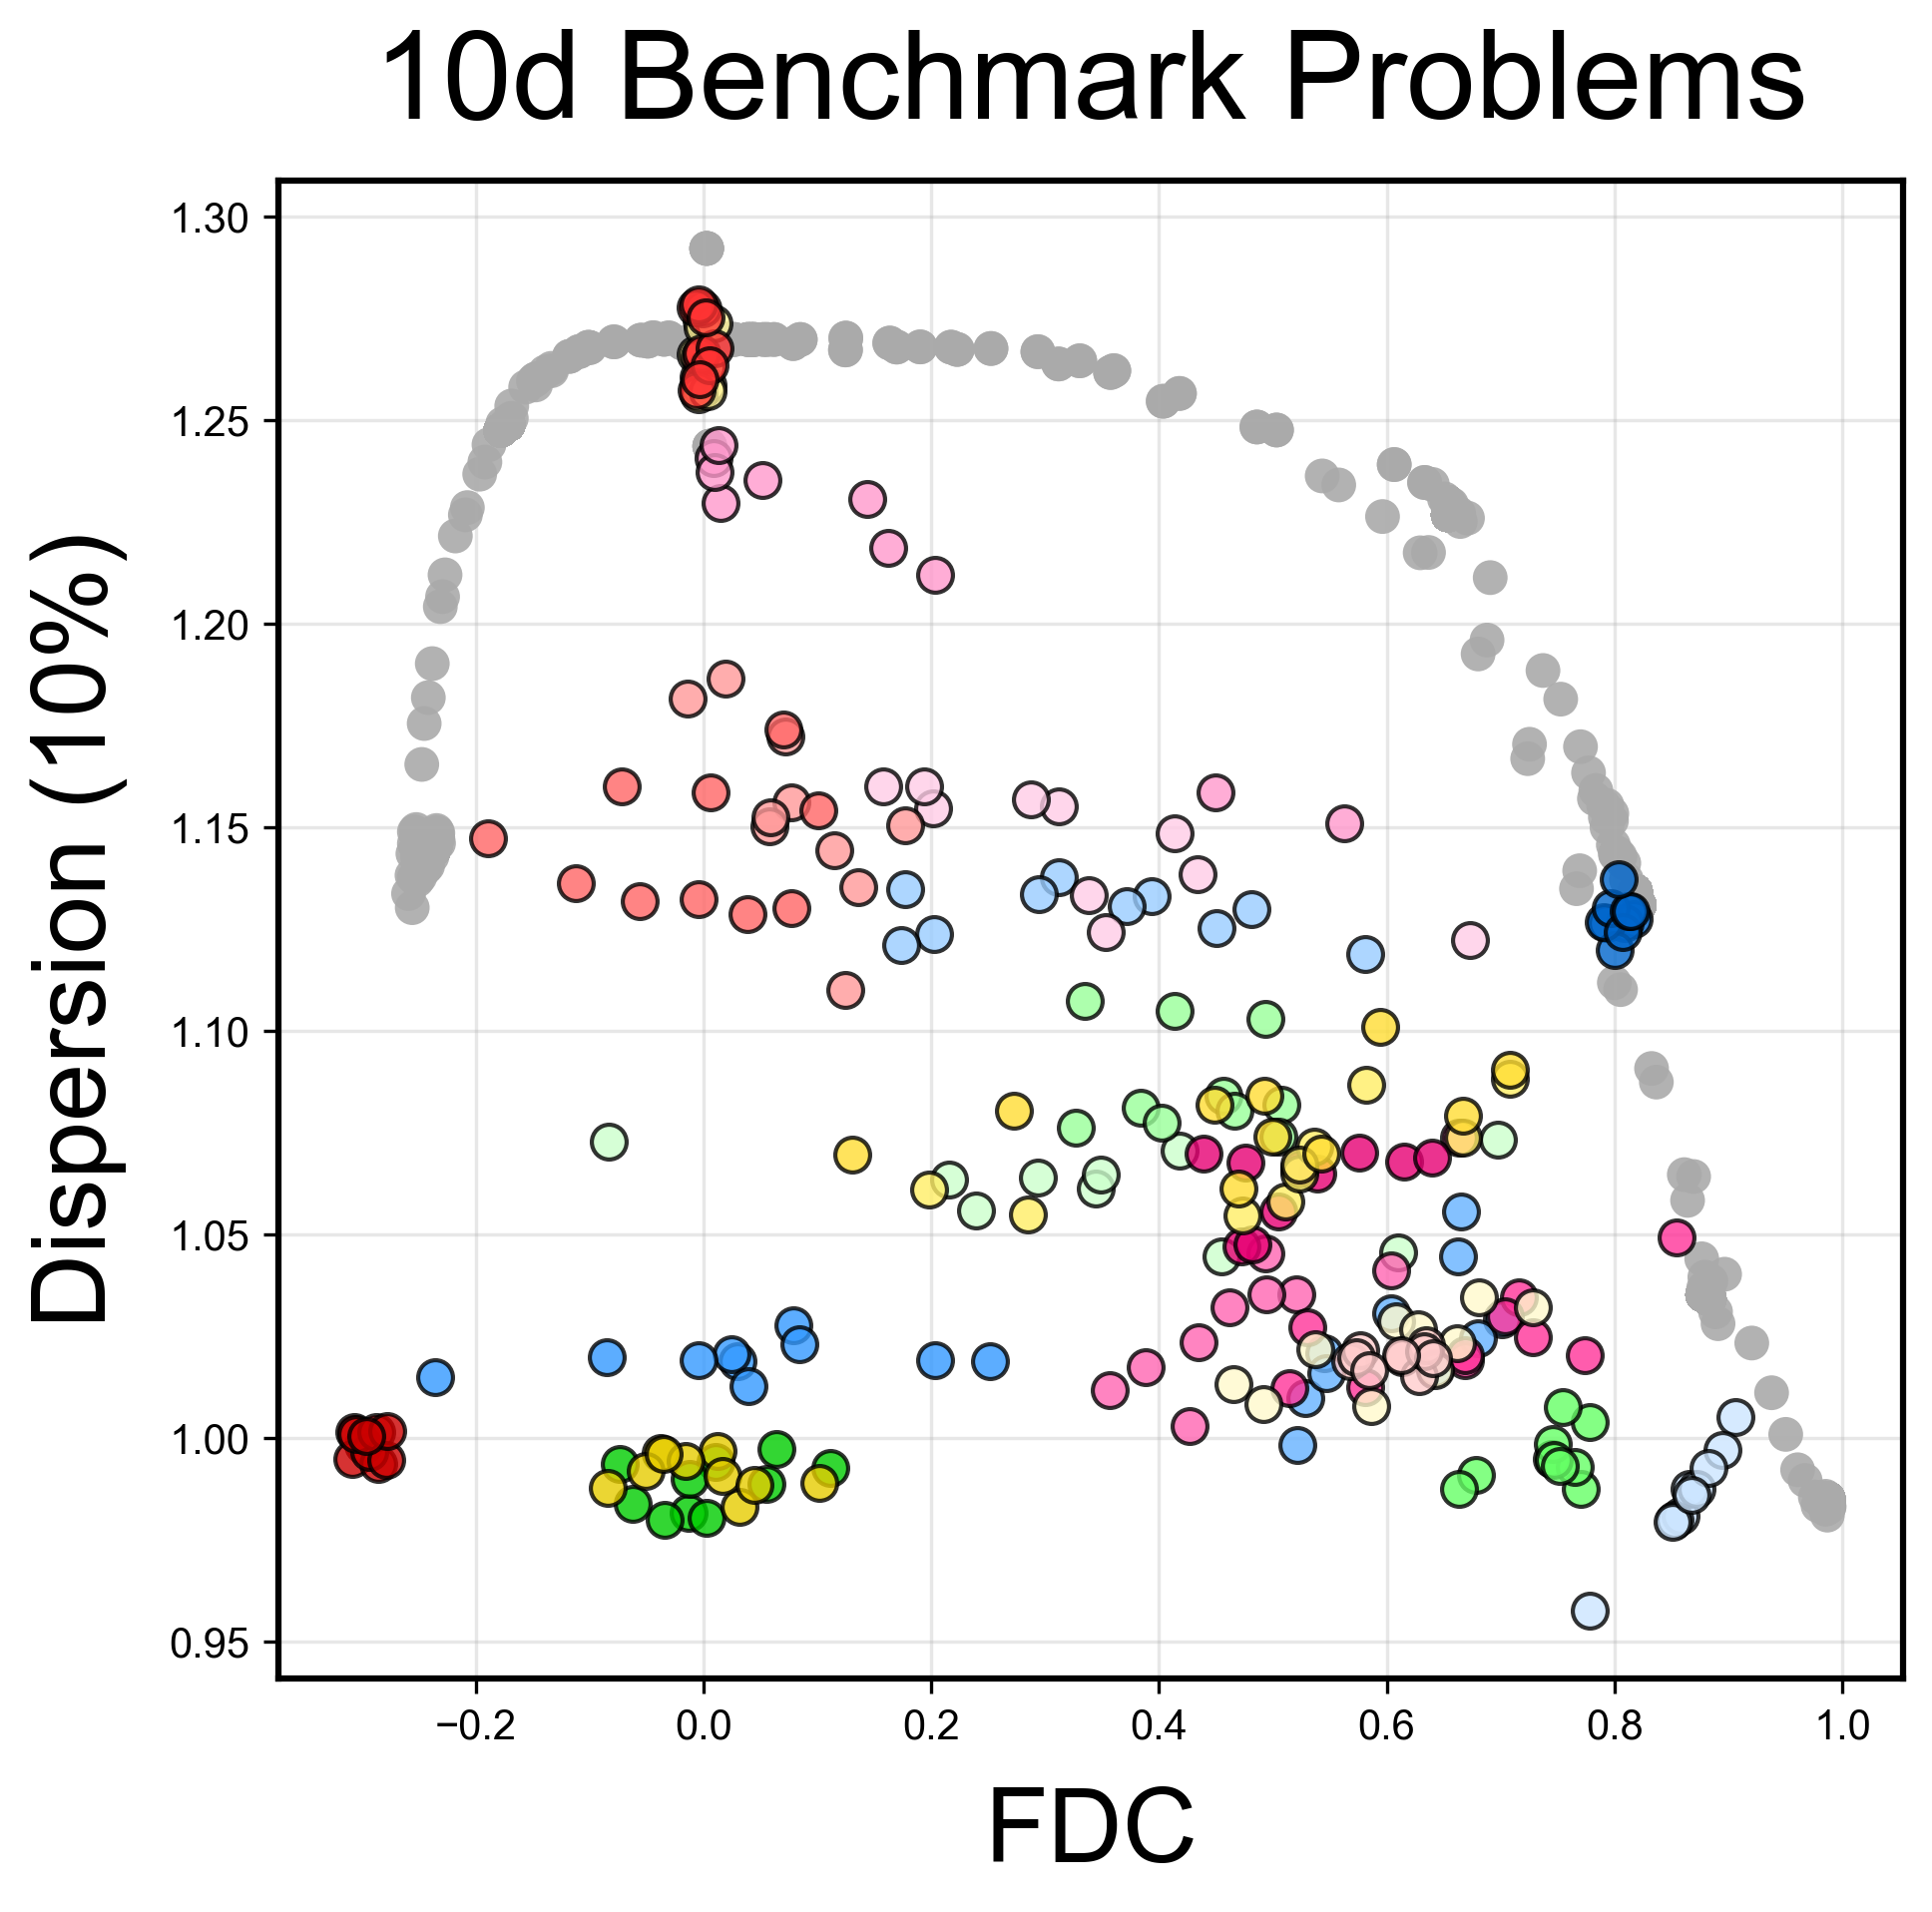

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
from pathlib import Path


rcParams["text.usetex"] = False
rcParams["font.family"] = "arial"
rcParams["mathtext.fontset"] = "cm"
rcParams["pdf.fonttype"] = 42
rcParams["ps.fonttype"] = 42
rcParams["figure.dpi"] = 300
rcParams["savefig.dpi"] = 300

for D in [2, 5, 10]:
        
    bbob = pd.read_csv(f"bbob_features_D{D}.csv")
    platemo = pd.read_csv(f"platemo_features_D{D}.csv")


    msg_color = "#aaaaaa"
    msg_ids = [0, 1, 10, 11, 100, 101, 110, 111]

    bbob_ids = list(range(1, 25))


    bbob_colors = [
        "#cce5ff", "#99ccff", "#66b2ff", "#3399ff", "#0066cc",
        "#ccffcc", "#99ff99", "#66ff66", "#00cc00",
        "#ffcce6", "#ff99cc", "#ff66b2", "#ff3399", "#e60073",
        "#fff9cc", "#fff399", "#ffee66", "#ffdd33", "#e6cc00",
        "#ffcccc", "#ff9999", "#ff6666", "#ff3333", "#cc0000",
    ]


    fig, ax = plt.subplots(figsize=(7, 6.5))

    for fid in msg_ids:
        sub = platemo[platemo["function_id"] == fid]
        ax.scatter(
            sub["fdc"],
            sub["dispersion"],
            c=msg_color,
            s=70,
            alpha=0.9,
            edgecolor="none",
            zorder=1,
        )

    for fid in bbob_ids:
        sub = bbob[bbob["function_id"] == fid]
        ax.scatter(
            sub["fdc"],
            sub["dispersion"],
            c=bbob_colors[fid - 1],
            s=70,
            alpha=0.8,
            edgecolor="k",
            linewidth=1,
            zorder=2,
            label=f"f{fid}",
        )

    # Labels
    ax.set_xlabel("FDC", fontsize=25)
    ax.set_ylabel("Dispersion (10%)", fontsize=25)
    ax.set_title(rf"{D}d Benchmark Problems", fontsize=30, pad=15)
    ax.grid(alpha=0.3)

    for spine in ax.spines.values():
        spine.set_linewidth(1.5)

    # Save
    output_path = Path(f"scatter_fdc_disp_{D}d_bbob.svg")
    plt.savefig(output_path, format="svg", bbox_inches="tight", transparent=True)
    plt.show()

In [ ]:

import pandas as pd
import plotly.express as px

df = pd.read_csv("platemo_features_D10.csv")

df["function_id"] = df["function_id"].astype(int).apply(lambda x: f"{x:03d}")

fig = px.scatter_3d(
    df,
    x="fdc",
    y="dispersion",
    z="num_local_optima",
    color="function_id",
    hover_data=["function_id", "instance_id", "fdc", "dispersion", "num_local_optima"],
    color_discrete_sequence=px.colors.qualitative.T10,
    title="PlatEMO MMMO landscape features (D=10)",
    opacity=0.75,
    category_orders={"function_id": sorted(df["function_id"].unique())},
)

fig.update_traces(marker=dict(size=4, line=dict(width=0)))
fig.update_layout(
    scene=dict(
        xaxis_title="FDC",
        yaxis_title="Dispersion (10%)",
        zaxis_title="# Local optima",
    ),
    legend=dict(title="function_id", itemsizing="constant"),
    width=900,
    height=700,
    margin=dict(l=0, r=0, t=50, b=0),
)

fig.write_html(
    "platemo_features_3d_D10.html",
    include_plotlyjs="cdn",
    full_html=True,
)
print("Saved: platemo_features_3d_D10.html")

Saved: platemo_features_3d_D10.html
